In [4]:
import os
import pandas as pd

# Get all files in the data directory
data_dir = 'data'
if os.path.exists(data_dir):
    files = os.listdir(data_dir)
    print(f"Files in '{data_dir}' directory:\n")
    
    for file in files:
        file_path = os.path.join(data_dir, file)
        print(f"{'='*50}")
        print(f"File: {file}")
        print(f"{'='*50}")
        
        # Handle different file types
        if file.endswith('.csv'):
            df = pd.read_csv(file_path)
            print(f"Shape: {df.shape}")
            print(f"Columns: {list(df.columns)}")
            print(f"\nFirst few rows:\n{df.head()}")
            print(f"\nData types:\n{df.dtypes}")
        elif file.endswith('.json'):
            df = pd.read_json(file_path)
            print(f"Shape: {df.shape}")
            print(f"Columns: {list(df.columns)}")
            print(f"\nFirst few rows:\n{df.head()}")
        elif file.endswith('.txt'):
            with open(file_path, 'r') as f:
                content = f.read()
            print(f"File size: {len(content)} characters")
            print(f"\nFirst 500 characters:\n{content[:500]}")
        else:
            print(f"File type: {os.path.splitext(file)[1]}")
            print(f"File size: {os.path.getsize(file_path)} bytes")
        
        print("\n")
else:
    print(f"'{data_dir}' directory not found.")

Files in 'data' directory:

File: kyc_individual.csv
Shape: (53099, 10)
Columns: ['customer_id', 'country', 'province', 'city', 'gender', 'marital_status', 'occupation_code', 'income', 'birth_date', 'onboard_date']

First few rows:
       customer_id country province  ...   income  birth_date onboard_date
0  SYNID0100000167      CA       ON  ...  48886.0  1972-01-30   2011-09-20
1  SYNID0100000431      CA      NaN  ...      NaN  1988-03-20   2018-06-04
2  SYNID0100000485      CA       ON  ...  19998.0  1935-05-02   1997-07-12
3  SYNID0100000539      CA      NaN  ...  39417.0  1944-11-04   1985-05-14
4  SYNID0100000932      CA       ON  ...  34182.0  1963-09-14   2012-07-09

[5 rows x 10 columns]

Data types:
customer_id            str
country                str
province               str
city                   str
gender                 str
marital_status         str
occupation_code        str
income             float64
birth_date             str
onboard_date           str
dtype: objec

In [22]:
import os
import pandas as pd

# Load datasets
labels_df = pd.read_csv(os.path.join(data_dir, "labels.csv"))
kyc_individual = pd.read_csv(os.path.join(data_dir, "kyc_individual.csv"))
kyc_smallbusinesses = pd.read_csv(os.path.join(data_dir, "kyc_smallbusiness.csv"))

# Pick the first column in labels.csv as label values if column name is unknown
label_col = labels_df.columns[0]
labels = labels_df[label_col].dropna().astype(str).unique()

def find_label_locations(df, label_values):
    locations = []
    for label in label_values:
        mask = df.astype(str).apply(lambda col: col.str.contains(label, na=False))
        if mask.any().any():
            rows, cols = mask.to_numpy().nonzero()
            locations.append({
                "label": label,
                "rows": rows.tolist(),
                "columns": [df.columns[c] for c in cols]
            })
    return locations

individual_locations = find_label_locations(kyc_individual, labels)
smallbusiness_locations = find_label_locations(kyc_smallbusinesses, labels)

association = {
    "kyc_individual": individual_locations,
    "kyc_smallbusiness": smallbusiness_locations
}

association

NameError: name 'data_dir' is not defined

In [9]:
print(len(individual_locations))
print(len(smallbusiness_locations))

912
88


In [10]:
# Extract labels from the association data
individual_labels = [loc['label'] for loc in individual_locations]
smallbusiness_labels = [loc['label'] for loc in smallbusiness_locations]

# Get the fraud labels from labels_df
fraud_labels = labels_df[labels_df['label'] == 1]['customer_id'].astype(str).unique()
non_fraud_labels = labels_df[labels_df['label'] == 0]['customer_id'].astype(str).unique()

# Count fraud vs non-fraud in individual locations
individual_fraud = sum(1 for label in individual_labels if label in fraud_labels)
individual_non_fraud = sum(1 for label in individual_labels if label in non_fraud_labels)

# Count fraud vs non-fraud in small business locations
smallbusiness_fraud = sum(1 for label in smallbusiness_labels if label in fraud_labels)
smallbusiness_non_fraud = sum(1 for label in smallbusiness_labels if label in non_fraud_labels)

# Display results
print("Individual KYC:")
print(f"  Fraud: {individual_fraud}")
print(f"  Non-Fraud: {individual_non_fraud}")
print(f"  Total: {individual_fraud + individual_non_fraud}")

print("\nSmall Business KYC:")
print(f"  Fraud: {smallbusiness_fraud}")
print(f"  Non-Fraud: {smallbusiness_non_fraud}")
print(f"  Total: {smallbusiness_fraud + smallbusiness_non_fraud}")

print(f"\nOverall:")
print(f"  Total Fraud: {individual_fraud + smallbusiness_fraud}")
print(f"  Total Non-Fraud: {individual_non_fraud + smallbusiness_non_fraud}")

Individual KYC:
  Fraud: 6
  Non-Fraud: 906
  Total: 912

Small Business KYC:
  Fraud: 4
  Non-Fraud: 84
  Total: 88

Overall:
  Total Fraud: 10
  Total Non-Fraud: 990


In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ealaxi/banksim1")

print("Path to dataset files:", path)

Path to dataset files: /student/minalex/.cache/kagglehub/datasets/ealaxi/banksim1/versions/1


In [4]:
import os
import pandas as pd

# List files in the banksim dataset directory
path = "banksim"
banksim_files = os.listdir("banksim")
print(f"Files in banksim dataset directory:\n")

for file in banksim_files:
    file_path = os.path.join(path, file)
    print(f"{'='*50}")
    print(f"File: {file}")
    print(f"{'='*50}")
    
    if file.endswith('.csv'):
        df_temp = pd.read_csv(file_path)
        print(f"Shape: {df_temp.shape}")
        print(f"Columns: {list(df_temp.columns)}")
        print(f"\nFirst few rows:\n{df_temp.head()}")
        print(f"\nData types:\n{df_temp.dtypes}")
    else:
        print(f"File type: {os.path.splitext(file)[1]}")
        print(f"File size: {os.path.getsize(file_path)} bytes")
    
    print("\n")

Files in banksim dataset directory:

File: bsNET140513_032310.csv
Shape: (594643, 5)
Columns: ['Source', 'Target', 'Weight', 'typeTrans', 'fraud']

First few rows:
          Source         Target  Weight            typeTrans  fraud
0  'C1093826151'   'M348934600'    4.55  'es_transportation'      0
1   'C352968107'   'M348934600'   39.68  'es_transportation'      0
2  'C2054744914'  'M1823072687'   26.89  'es_transportation'      0
3  'C1760612790'   'M348934600'   17.25  'es_transportation'      0
4   'C757503768'   'M348934600'   35.72  'es_transportation'      0

Data types:
Source           str
Target           str
Weight       float64
typeTrans        str
fraud          int64
dtype: object


File: bs140513_032310.csv
Shape: (594643, 10)
Columns: ['step', 'customer', 'age', 'gender', 'zipcodeOri', 'merchant', 'zipMerchant', 'category', 'amount', 'fraud']

First few rows:
   step       customer  age gender zipcodeOri       merchant zipMerchant  \
0     0  'C1093826151'  '4'    'M'  

In [25]:
# Check categories in the BankSim dataset
banksim_df = pd.read_csv('banksim/bs140513_032310.csv')

print("BankSim Dataset - Category Analysis:")
print("="*80)
print(f"\nDataset shape: {banksim_df.shape}")
print(f"\nColumn 'category' exists: {'category' in banksim_df.columns}")

if 'category' in banksim_df.columns:
    print(f"\nUnique categories: {banksim_df['category'].nunique()}")
    print(f"\nCategory distribution:")
    print(banksim_df['category'].value_counts().sort_index())
    
    print(f"\nCategory distribution (%):")
    print(banksim_df['category'].value_counts(normalize=True).sort_index() * 100)
    
    print(f"\nFraud rate by category:")
    fraud_by_category = banksim_df.groupby('category')['fraud'].agg(['sum', 'count', 'mean'])
    fraud_by_category.columns = ['Fraud_Count', 'Total_Transactions', 'Fraud_Rate']
    fraud_by_category['Fraud_Rate'] = fraud_by_category['Fraud_Rate'] * 100
    print(fraud_by_category.sort_values('Fraud_Rate', ascending=False))
else:
    print("\n⚠️ 'category' column not found in BankSim dataset")
    print(f"Available columns: {banksim_df.columns.tolist()}")

BankSim Dataset - Category Analysis:

Dataset shape: (594643, 10)

Column 'category' exists: True

Unique categories: 15

Category distribution:
category
'es_barsandrestaurants'      6373
'es_contents'                 885
'es_fashion'                 6454
'es_food'                   26254
'es_health'                 16133
'es_home'                    1986
'es_hotelservices'           1744
'es_hyper'                   6098
'es_leisure'                  499
'es_otherservices'            912
'es_sportsandtoys'           4002
'es_tech'                    2370
'es_transportation'        505119
'es_travel'                   728
'es_wellnessandbeauty'      15086
Name: count, dtype: int64

Category distribution (%):
category
'es_barsandrestaurants'     1.071735
'es_contents'               0.148829
'es_fashion'                1.085357
'es_food'                   4.415086
'es_health'                 2.713056
'es_home'                   0.333982
'es_hotelservices'          0.293285
'es_hyper'    

In [5]:
# Count fraud and non-fraud in the banksim dataset
fraud_count = (df_temp['fraud'] == 1).sum()
non_fraud_count = (df_temp['fraud'] == 0).sum()

print("BankSim Dataset - Fraud Distribution:")
print(f"  Fraud: {fraud_count}")
print(f"  Non-Fraud: {non_fraud_count}")
print(f"  Total: {len(df_temp)}")
print(f"  Fraud Percentage: {fraud_count / len(df_temp) * 100:.2f}%")

BankSim Dataset - Fraud Distribution:
  Fraud: 7200
  Non-Fraud: 587443
  Total: 594643
  Fraud Percentage: 1.21%


In [8]:
import pandas as pd
import os

# 1. Load Data
banksim_df = pd.read_csv(os.path.join("banksim", "bs140513_032310.csv"))
kyc_combined = pd.concat([kyc_individual, kyc_smallbusinesses], axis=0, ignore_index=True)

# 2. Inspect the schemas first
print("BankSim columns:", banksim_df.columns.tolist())
print("\nKYC Combined columns:", kyc_combined.columns.tolist())
print("\nBankSim shape:", banksim_df.shape)
print("KYC Combined shape:", kyc_combined.shape)

# 3. Schema Mapping for BankSim
banksim_prepared = banksim_df.rename(columns={
    'customer': 'customer_id',
    'category': 'transaction_type',
    'amount': 'transaction_amount'
})

print("\nBankSim prepared columns:", banksim_prepared.columns.tolist())

BankSim columns: ['step', 'customer', 'age', 'gender', 'zipcodeOri', 'merchant', 'zipMerchant', 'category', 'amount', 'fraud']

KYC Combined columns: ['customer_id', 'country', 'province', 'city', 'gender', 'marital_status', 'occupation_code', 'income', 'birth_date', 'onboard_date', 'industry_code', 'employee_count', 'sales', 'established_date']

BankSim shape: (594643, 10)
KYC Combined shape: (61410, 14)

BankSim prepared columns: ['step', 'customer_id', 'age', 'gender', 'zipcodeOri', 'merchant', 'zipMerchant', 'transaction_type', 'transaction_amount', 'fraud']


In [19]:
# Identify overlapping columns between the two datasets
banksim_cols = set(banksim_prepared.columns)
kyc_cols = set(kyc_combined.columns)

overlapping_cols = banksim_cols.intersection(kyc_cols)
print(f"Overlapping columns: {overlapping_cols}")

# These columns will cause _x and _y suffixes if we don't handle them
# We need to decide which to keep or how to merge them

Overlapping columns: {'gender', 'customer_id'}


In [20]:
# Strategy for combining datasets:
# Merge KYC data WITH transaction data (JOIN) to enrich transactions with customer profile information

if 'customer_id' in kyc_combined.columns:
    # Identify which columns overlap (excluding customer_id which is our merge key)
    banksim_cols = set(banksim_prepared.columns)
    kyc_cols = set(kyc_combined.columns)
    overlapping_cols = (banksim_cols.intersection(kyc_cols)) - {'customer_id'}
    
    if overlapping_cols:
        print(f"Found {len(overlapping_cols)} overlapping columns: {overlapping_cols}")
        print("Strategy: Keeping BankSim version for transaction-level data, dropping duplicates from KYC")
        
        # Drop overlapping columns from KYC (keep only KYC-specific profile columns)
        kyc_to_merge = kyc_combined.drop(columns=list(overlapping_cols))
        print(f"KYC columns after dropping duplicates: {kyc_to_merge.columns.tolist()}")
    else:
        kyc_to_merge = kyc_combined
        print("No overlapping columns found")
    
    # Now merge without creating _x/_y duplicates
    combined_df = banksim_prepared.merge(
        kyc_to_merge, 
        on='customer_id', 
        how='left'  # Keep all transactions, add KYC data where available
    )
    print(f"\nMerged DataFrame shape: {combined_df.shape}")
    print(f"Merged DataFrame columns ({len(combined_df.columns)}): {combined_df.columns.tolist()}")
else:
    print("\nNo customer_id column found in KYC data. Available columns:", kyc_combined.columns.tolist())
    print("Using BankSim data only (no KYC merge)")
    combined_df = banksim_prepared
    
print("\nFirst few rows of result:")
print(combined_df.head())

Found 1 overlapping columns: {'gender'}
Strategy: Keeping BankSim version for transaction-level data, dropping duplicates from KYC
KYC columns after dropping duplicates: ['customer_id', 'country', 'province', 'city', 'marital_status', 'occupation_code', 'income', 'birth_date', 'onboard_date', 'industry_code', 'employee_count', 'sales', 'established_date']

Merged DataFrame shape: (594643, 22)
Merged DataFrame columns (22): ['step', 'customer_id', 'age', 'gender', 'zipcodeOri', 'merchant', 'zipMerchant', 'transaction_type', 'transaction_amount', 'fraud', 'country', 'province', 'city', 'marital_status', 'occupation_code', 'income', 'birth_date', 'onboard_date', 'industry_code', 'employee_count', 'sales', 'established_date']

First few rows of result:
   step    customer_id  age  ... employee_count sales established_date
0     0  'C1093826151'  '4'  ...            NaN   NaN              NaN
1     0   'C352968107'  '2'  ...            NaN   NaN              NaN
2     0  'C2054744914'  '4' 

In [21]:
# Verify no duplicate columns (_x, _y suffixes)
duplicate_suffixes = [col for col in combined_df.columns if col.endswith('_x') or col.endswith('_y')]

if duplicate_suffixes:
    print(f"⚠️ WARNING: Found {len(duplicate_suffixes)} columns with _x/_y suffixes:")
    print(duplicate_suffixes)
    print("\nThis indicates merge issues. Please review the merge logic above.")
else:
    print("✓ No duplicate columns found! Merge was successful.")
    
print(f"\nData types summary:")
print(combined_df.dtypes.value_counts())

✓ No duplicate columns found! Merge was successful.

Data types summary:
str        16
float64     4
int64       2
Name: count, dtype: int64


In [22]:
# Prepare data for CTabSyn training
# CTabSyn needs numeric inputs, so convert categorical columns to codes

# Make a copy to avoid modifying the original
df_for_training = combined_df.copy()

# Convert object/categorical columns to numeric codes
for col in df_for_training.select_dtypes(include=['object', 'category']).columns:
    df_for_training[col] = df_for_training[col].astype('category').cat.codes

# Handle missing values - replace with -1 or use appropriate strategy
df_for_training = df_for_training.fillna(-1)

print(f"\nFinal training DataFrame shape: {df_for_training.shape}")
print(f"Columns: {df_for_training.columns.tolist()}")
print(f"\nData types:\n{df_for_training.dtypes}")
print(f"\nFirst few rows:\n{df_for_training.head()}")

# Check if 'fraud' column exists for supervised training
if 'fraud' in df_for_training.columns:
    print(f"\nFraud distribution:")
    print(df_for_training['fraud'].value_counts())
else:
    print("\nWarning: No 'fraud' column found. Available columns:", df_for_training.columns.tolist())

/tmp/ipykernel_102807/4094984046.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_for_training.select_dtypes(include=['object', 'category']).columns:



Final training DataFrame shape: (594643, 22)
Columns: ['step', 'customer_id', 'age', 'gender', 'zipcodeOri', 'merchant', 'zipMerchant', 'transaction_type', 'transaction_amount', 'fraud', 'country', 'province', 'city', 'marital_status', 'occupation_code', 'income', 'birth_date', 'onboard_date', 'industry_code', 'employee_count', 'sales', 'established_date']

Data types:
step                    int64
customer_id             int16
age                      int8
gender                   int8
zipcodeOri               int8
merchant                 int8
zipMerchant              int8
transaction_type         int8
transaction_amount    float64
fraud                   int64
country                  int8
province                 int8
city                     int8
marital_status           int8
occupation_code          int8
income                float64
birth_date               int8
onboard_date             int8
industry_code            int8
employee_count        float64
sales                 float

In [23]:
# Train CTabSyn and generate synthetic data
from CTabSyn import train_and_generate

# Now train with the properly prepared data
final_augmented_data = train_and_generate(df_for_training)

print(f"\nGenerated synthetic data shape: {final_augmented_data.shape}")
print(f"Synthetic data columns: {final_augmented_data.columns.tolist()}")

Performing Overlap Region Detection...
Training VAE...
Generating 52264 synthetic fraud samples...

Generated synthetic data shape: (646907, 22)
Synthetic data columns: ['step', 'customer_id', 'age', 'gender', 'zipcodeOri', 'merchant', 'zipMerchant', 'transaction_type', 'transaction_amount', 'fraud', 'country', 'province', 'city', 'marital_status', 'occupation_code', 'income', 'birth_date', 'onboard_date', 'industry_code', 'employee_count', 'sales', 'established_date']


In [24]:
# Write the synthetic data to CSV
final_augmented_data.to_csv('final_augmented_data.csv', index=False)
print(f"Synthetic data saved to 'final_augmented_data.csv'")
print(f"File contains {len(final_augmented_data)} rows and {len(final_augmented_data.columns)} columns")

Synthetic data saved to 'final_augmented_data.csv'
File contains 646907 rows and 22 columns


In [25]:
# Check fraud distribution
fraud_distribution = final_augmented_data['fraud'].value_counts()
print("Fraud Distribution:")
print(fraud_distribution)
print(f"\nFraud Percentage: {fraud_distribution[1] / len(final_augmented_data) * 100:.2f}%")
print(f"Non-Fraud Percentage: {fraud_distribution[0] / len(final_augmented_data) * 100:.2f}%")

# Distribution of all features
print("\n" + "="*80)
print("Feature Distributions:")
print("="*80)

for col in final_augmented_data.columns:
    print(f"\n{col}:")
    print(f"  Data Type: {final_augmented_data[col].dtype}")
    print(f"  Non-null Count: {final_augmented_data[col].notna().sum()}")
    print(f"  Null Count: {final_augmented_data[col].isna().sum()}")
    print(f"  Min: {final_augmented_data[col].min()}")
    print(f"  Max: {final_augmented_data[col].max()}")
    print(f"  Mean: {final_augmented_data[col].mean():.2f}")
    print(f"  Std Dev: {final_augmented_data[col].std():.2f}")
    
    # Show value counts for categorical-like columns (when less than 20 unique values)
    if final_augmented_data[col].nunique() <= 20:
        print(f"  Value Counts:\n{final_augmented_data[col].value_counts().head(10)}")

Fraud Distribution:
fraud
0    587443
1     59464
Name: count, dtype: int64

Fraud Percentage: 9.19%
Non-Fraud Percentage: 90.81%

Feature Distributions:

step:
  Data Type: float64
  Non-null Count: 646907
  Null Count: 0
  Min: 0.0
  Max: 179.0
  Mean: 94.66
  Std Dev: 48.96

customer_id:
  Data Type: float64
  Non-null Count: 646907
  Null Count: 0
  Min: 0.0
  Max: 4111.0
  Mean: 2044.83
  Std Dev: 1136.63

age:
  Data Type: float64
  Non-null Count: 646907
  Null Count: 0
  Min: 0.0
  Max: 7.0
  Mean: 3.01
  Std Dev: 1.28

gender:
  Data Type: float64
  Non-null Count: 646907
  Null Count: 0
  Min: 0.0
  Max: 3.0
  Mean: 1.44
  Std Dev: 0.48

zipcodeOri:
  Data Type: float64
  Non-null Count: 646907
  Null Count: 0
  Min: 0.0
  Max: 6.919191946508362e-13
  Mean: 0.00
  Std Dev: 0.00

merchant:
  Data Type: float64
  Non-null Count: 646907
  Null Count: 0
  Min: 0.0
  Max: 49.0
  Mean: 24.51
  Std Dev: 8.51

zipMerchant:
  Data Type: float64
  Non-null Count: 646907
  Null Count: 0

In [26]:
import torch
import pandas as pd
import numpy as np

def create_graph_data(df):
    # 1. Identify Unique Entities
    customers = df['customer_id'].unique()
    merchants = df['merchant'].unique()
    
    # Create mapping: ID -> Index
    # We stack them so Customers are indices [0...num_cust-1] 
    # and Merchants are [num_cust...num_cust+num_merch-1]
    node_map = {id: i for i, id in enumerate(np.concatenate([customers, merchants]))}
    num_customers = len(customers)
    num_nodes = len(node_map)
    
    # 2. Build Edge Index (Source -> Target)
    # GAT expects a tensor of shape [2, num_edges]
    src = df['customer_id'].map(node_map).values
    dst = df['merchant'].map(node_map).values
    
    # Convert to tensor efficiently using numpy.stack first
    edge_index = torch.from_numpy(np.stack([src, dst])).long()
    
    # 3. Create Node Feature Matrix (X)
    # We need to aggregate transaction data into "Profiles" for each node
    
    # Customer Features: Demographics + Aggregated Transaction Stats
    cust_features = df.groupby('customer_id').agg({
        'transaction_amount': ['mean', 'std', 'count'],
        'income': 'first',
        'age': 'first'
        # Add other KYC features here (occupation, etc.)
    }).fillna(0)
    
    # Merchant Features: Aggregate Transaction Stats
    merch_features = df.groupby('merchant').agg({
        'transaction_amount': ['mean', 'std', 'count'],
        'fraud': 'mean' # Historical fraud rate for this merchant
    }).fillna(0)
    
    # Align features: Both types must have the same feature dimension for a standard GAT
    # We will pad merchant features with zeros for the demographic columns they don't have
    # For a Week-1 sprint, it's easiest to use a shared feature set
    
    # 4. Extract Labels (y)
    # For customers, 1 if they have ANY fraud transaction in the augmented set
    cust_labels = df.groupby('customer_id')['fraud'].max().values
    # Merchants usually don't have 'labels' in the same way, we can set them to -1 (ignore)
    node_labels = np.concatenate([cust_labels, np.full(len(merchants), -1)])
    
    return edge_index, cust_features, merch_features, torch.tensor(node_labels)

edge_index, X_cust, X_merch, y = create_graph_data(final_augmented_data)

In [27]:
# Show one customer node's feature row
sample_customer_id = X_cust.index[0]
print(f"Customer node id: {sample_customer_id}")
print(X_cust.loc[sample_customer_id])

# Show one merchant node's feature row
sample_merchant_id = X_merch.index[0]
print(f"\nMerchant node id: {sample_merchant_id}")
print(X_merch.loc[sample_merchant_id])

Customer node id: 0.0
transaction_amount  mean      35.091908
                    std       36.863536
                    count    131.000000
income              first     -1.000000
age                 first      5.000000
Name: 0.0, dtype: float64

Merchant node id: 0.0
transaction_amount  mean      103.072322
                    std        76.171158
                    count    6821.000000
fraud               mean        0.000000
Name: 0.0, dtype: float64


In [28]:
# Print one customer node (first row)
print("One customer node:")
print(X_cust.iloc[0])

One customer node:
transaction_amount  mean      35.091908
                    std       36.863536
                    count    131.000000
income              first     -1.000000
age                 first      5.000000
Name: 0.0, dtype: float64


## Random Forest Model for Fraud Detection

Train a Random Forest classifier on the augmented data to detect fraud and identify important features.

In [1]:
# Import required libraries for model training
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, average_precision_score, precision_recall_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully")

Libraries imported successfully


In [4]:
import pandas as pd
# Load the final augmented data from CSV
final_augmented_data = pd.read_csv('final_augmented_data.csv')

print(f"Data loaded successfully!")
print(f"Shape: {final_augmented_data.shape}")
print(f"Columns: {final_augmented_data.columns.tolist()}")
print(f"\nFirst few rows:")
print(final_augmented_data.head())

Data loaded successfully!
Shape: (646907, 22)
Columns: ['step', 'customer_id', 'age', 'gender', 'zipcodeOri', 'merchant', 'zipMerchant', 'transaction_type', 'transaction_amount', 'fraud', 'country', 'province', 'city', 'marital_status', 'occupation_code', 'income', 'birth_date', 'onboard_date', 'industry_code', 'employee_count', 'sales', 'established_date']

First few rows:
         step  customer_id      age    gender    zipcodeOri   merchant  \
0   45.000000  2094.000000  4.00000  2.000000  0.000000e+00  30.000000   
1   52.000000  2298.000000  5.00000  1.000000  0.000000e+00  30.000000   
2  155.000000  2194.000000  6.00000  1.000000  0.000000e+00  18.000000   
3   89.579806  2076.470314  2.95076  1.324846  1.100785e-13  32.600603   
4  106.000000  3043.000000  3.00000  2.000000  0.000000e+00  30.000000   

    zipMerchant  transaction_type  transaction_amount  fraud  ...  city  \
0  0.000000e+00         12.000000           17.380000      0  ...  -1.0   
1  0.000000e+00         12.0

In [5]:
# 1. Inspect the data before preparing features
print("Final Augmented Data Info:")
print(f"Shape: {final_augmented_data.shape}")
print(f"Columns: {final_augmented_data.columns.tolist()}")
print(f"\nFraud distribution:")
print(final_augmented_data['fraud'].value_counts())
print(f"\nData types:")
print(final_augmented_data.dtypes)

Final Augmented Data Info:
Shape: (646907, 22)
Columns: ['step', 'customer_id', 'age', 'gender', 'zipcodeOri', 'merchant', 'zipMerchant', 'transaction_type', 'transaction_amount', 'fraud', 'country', 'province', 'city', 'marital_status', 'occupation_code', 'income', 'birth_date', 'onboard_date', 'industry_code', 'employee_count', 'sales', 'established_date']

Fraud distribution:
fraud
0    587443
1     59464
Name: count, dtype: int64

Data types:
step                  float64
customer_id           float64
age                   float64
gender                float64
zipcodeOri            float64
merchant              float64
zipMerchant           float64
transaction_type      float64
transaction_amount    float64
fraud                   int64
country               float64
province              float64
city                  float64
marital_status        float64
occupation_code       float64
income                float64
birth_date            float64
onboard_date          float64
industry_

### 🔍 Diagnostic: Check KYC Feature Encoding

Before training, let's verify that KYC features (income, occupation_code, industry_code, marital_status) were properly merged and encoded.

In [14]:
# Check if KYC features exist in the dataset
kyc_features = ['income', 'occupation_code', 'industry_code', 'marital_status', 'age', 'gender']

print("KYC Feature Existence Check:")
print("="*80)
for feature in kyc_features:
    if feature in final_augmented_data.columns:
        print(f"✓ {feature}: EXISTS")
    else:
        print(f"✗ {feature}: MISSING")

print("\n" + "="*80)
print("All columns in final_augmented_data:")
print("="*80)
print(final_augmented_data.columns.tolist())

KYC Feature Existence Check:
✓ income: EXISTS
✓ occupation_code: EXISTS
✓ industry_code: EXISTS
✓ marital_status: EXISTS
✓ age: EXISTS
✓ gender: EXISTS

All columns in final_augmented_data:
['step', 'customer_id', 'age', 'gender', 'zipcodeOri', 'merchant', 'zipMerchant', 'transaction_type', 'transaction_amount', 'fraud', 'country', 'province', 'city', 'marital_status', 'occupation_code', 'income', 'birth_date', 'onboard_date', 'industry_code', 'employee_count', 'sales', 'established_date']


In [15]:
# Check the actual values and distributions of KYC features
print("KYC Feature Value Analysis:")
print("="*80)

for feature in kyc_features:
    if feature in final_augmented_data.columns:
        print(f"\n{feature.upper()}:")
        print(f"  Data Type: {final_augmented_data[feature].dtype}")
        print(f"  Unique Values: {final_augmented_data[feature].nunique()}")
        print(f"  Null Count: {final_augmented_data[feature].isna().sum()}")
        print(f"  Null %: {final_augmented_data[feature].isna().sum() / len(final_augmented_data) * 100:.2f}%")
        print(f"  Min: {final_augmented_data[feature].min()}")
        print(f"  Max: {final_augmented_data[feature].max()}")
        print(f"  Mean: {final_augmented_data[feature].mean():.4f}")
        print(f"  Std: {final_augmented_data[feature].std():.4f}")
        
        # Show value counts for categorical-like data
        if final_augmented_data[feature].nunique() <= 20:
            print(f"  Value Counts:")
            print(final_augmented_data[feature].value_counts().head(10))
        else:
            print(f"  Sample Values: {final_augmented_data[feature].head(10).tolist()}")
        print("-" * 80)

KYC Feature Value Analysis:

INCOME:
  Data Type: float64
  Unique Values: 1747
  Null Count: 0
  Null %: 0.00%
  Min: -1.0
  Max: -0.9999999999992882
  Mean: -1.0000
  Std: 0.0000
  Sample Values: [-1.0, -1.0, -1.0, -0.999999999999888, -1.0, -1.0, -1.0, -1.0, -0.9999999999998256, -1.0]
--------------------------------------------------------------------------------

OCCUPATION_CODE:
  Data Type: float64
  Unique Values: 1663
  Null Count: 0
  Null %: 0.00%
  Min: -1.0
  Max: -0.9999999999993272
  Mean: -1.0000
  Std: 0.0000
  Sample Values: [-1.0, -1.0, -1.0, -0.9999999999998892, -1.0, -1.0, -1.0, -1.0, -0.999999999999829, -1.0]
--------------------------------------------------------------------------------

INDUSTRY_CODE:
  Data Type: float64
  Unique Values: 1735
  Null Count: 0
  Null %: 0.00%
  Min: -1.0
  Max: -0.9999999999993004
  Mean: -1.0000
  Std: 0.0000
  Sample Values: [-1.0, -1.0, -1.0, -0.9999999999998794, -1.0, -1.0, -1.0, -1.0, -0.9999999999998158, -1.0]
-------------

In [16]:
# Check if features are constant (all same value) or mostly missing
print("Constant/Missing Feature Detection:")
print("="*80)

problematic_features = []

for feature in kyc_features:
    if feature in final_augmented_data.columns:
        unique_count = final_augmented_data[feature].nunique()
        null_pct = final_augmented_data[feature].isna().sum() / len(final_augmented_data) * 100
        
        # Check if constant (only 1 unique value)
        if unique_count == 1:
            print(f"⚠️  {feature}: CONSTANT - Only 1 unique value: {final_augmented_data[feature].unique()[0]}")
            problematic_features.append(feature)
        
        # Check if mostly null (>80%)
        elif null_pct > 80:
            print(f"⚠️  {feature}: MOSTLY MISSING - {null_pct:.1f}% null values")
            problematic_features.append(feature)
        
        # Check if low variance (only 2-3 unique values in large dataset)
        elif unique_count <= 3 and len(final_augmented_data) > 1000:
            print(f"⚠️  {feature}: LOW VARIANCE - Only {unique_count} unique values")
            print(f"     Values: {final_augmented_data[feature].unique()}")
            problematic_features.append(feature)
        
        else:
            print(f"✓  {feature}: OK - {unique_count} unique values, {null_pct:.1f}% null")

if problematic_features:
    print(f"\n{'='*80}")
    print(f"🚨 FOUND {len(problematic_features)} PROBLEMATIC FEATURES:")
    print(problematic_features)
    print("These features will NOT be useful for the model!")
else:
    print(f"\n{'='*80}")
    print("✓ All KYC features appear to have good variance")

Constant/Missing Feature Detection:
✓  income: OK - 1747 unique values, 0.0% null
✓  occupation_code: OK - 1663 unique values, 0.0% null
✓  industry_code: OK - 1735 unique values, 0.0% null
✓  marital_status: OK - 1680 unique values, 0.0% null
✓  age: OK - 37284 unique values, 0.0% null
✓  gender: OK - 44481 unique values, 0.0% null

✓ All KYC features appear to have good variance


In [17]:
# Trace the source: Check if KYC features exist in ORIGINAL data before CTabSyn
# This will help identify if the problem is in the merge or in CTabSyn generation

print("Checking if KYC data was properly merged BEFORE CTabSyn:")
print("="*80)

# Check if we have access to combined_df (the pre-CTabSyn data)
try:
    # This would be the dataframe before CTabSyn if it's still in memory
    # If kernel was restarted, we need to trace back through the CSV files
    
    print("\nAttempting to load original combined data...")
    print("Note: If kernel was restarted, we may need to re-run earlier cells")
    
    # Check BankSim original schema
    banksim_check = pd.read_csv('banksim/bs140513_032310.csv', nrows=5)
    print(f"\nBankSim columns: {banksim_check.columns.tolist()}")
    
    # Check KYC data
    kyc_ind_check = pd.read_csv('data/kyc_individual.csv', nrows=5)
    kyc_sb_check = pd.read_csv('data/kyc_smallbusiness.csv', nrows=5)
    
    print(f"\nKYC Individual columns: {kyc_ind_check.columns.tolist()}")
    print(f"KYC SmallBusiness columns: {kyc_sb_check.columns.tolist()}")
    
    # Look for overlap
    kyc_all_cols = set(kyc_ind_check.columns) | set(kyc_sb_check.columns)
    banksim_cols_set = set(banksim_check.columns)
    
    print(f"\n{'='*80}")
    print("KYC-specific columns (should be in final data):")
    kyc_specific = kyc_all_cols - banksim_cols_set
    print(sorted(list(kyc_specific)))
    
except Exception as e:
    print(f"Error loading original data: {e}")
    print("You may need to re-run the earlier cells to access the original dataframes")

Checking if KYC data was properly merged BEFORE CTabSyn:

Attempting to load original combined data...
Note: If kernel was restarted, we may need to re-run earlier cells

BankSim columns: ['step', 'customer', 'age', 'gender', 'zipcodeOri', 'merchant', 'zipMerchant', 'category', 'amount', 'fraud']

KYC Individual columns: ['customer_id', 'country', 'province', 'city', 'gender', 'marital_status', 'occupation_code', 'income', 'birth_date', 'onboard_date']
KYC SmallBusiness columns: ['customer_id', 'country', 'province', 'city', 'industry_code', 'employee_count', 'sales', 'established_date', 'onboard_date']

KYC-specific columns (should be in final data):
['birth_date', 'city', 'country', 'customer_id', 'employee_count', 'established_date', 'income', 'industry_code', 'marital_status', 'occupation_code', 'onboard_date', 'province', 'sales']


### 📊 Root Cause Analysis

**Potential Issues:**
1. **KYC features missing from merge**: The BankSim and KYC data may not have been properly joined
2. **CTabSyn dropped the features**: The VAE might not have preserved KYC features during generation
3. **Features were all NaN/constant**: Original KYC data may have missing values that became -1 during encoding
4. **Column name mismatch**: Features exist but under different names (e.g., `income` vs `customer_income`)

**What to look for in the diagnostics above:**
- Are KYC features present in `final_augmented_data.columns`?
- Do they have only 1 unique value (constant)?
- Are they mostly NULL/NaN?
- Do they exist in the original BankSim vs KYC data?

In [19]:
# Summary: Compare feature variance before and after encoding
print("Feature Variance Analysis (for features used in Random Forest):")
print("="*80)

# The diagnostic above shows the problem clearly:
# income, occupation_code, industry_code, marital_status are ALL ~-1.0
# This means they were NaN in the original data and got filled with -1

print("\n🚨 ROOT CAUSE IDENTIFIED:")
print("="*80)
print("KYC features (income, occupation_code, industry_code, marital_status)")
print("are ALL approximately -1.0 (Mean=-1.0, Std=0.0000)")
print("\nThis means:")
print("  1. These features were NaN/missing in the original merged data")
print("  2. They got filled with -1 during preprocessing (fillna(-1))")
print("  3. CTabSyn learned to generate them as -1")
print("  4. Random Forest correctly assigns them 0.0 importance (they're constant!)")

print("\n" + "="*80)
print("🔍 NEXT STEP: Check why KYC merge produced NaN values")
print("="*80)
print("Theory: BankSim customer IDs don't match KYC customer IDs")
print("       OR: The merge happened but KYC data itself had NaN values")

Feature Variance Analysis (for features used in Random Forest):

🚨 ROOT CAUSE IDENTIFIED:
KYC features (income, occupation_code, industry_code, marital_status)
are ALL approximately -1.0 (Mean=-1.0, Std=0.0000)

This means:
  1. These features were NaN/missing in the original merged data
  2. They got filled with -1 during preprocessing (fillna(-1))
  3. CTabSyn learned to generate them as -1
  4. Random Forest correctly assigns them 0.0 importance (they're constant!)

🔍 NEXT STEP: Check why KYC merge produced NaN values
Theory: BankSim customer IDs don't match KYC customer IDs
       OR: The merge happened but KYC data itself had NaN values


### 🚨 CONFIRMED: KYC Features Are All -1 (Missing Data Issue)

**Problem Found:**
- All KYC features (income, occupation_code, industry_code, marital_status) have values ≈ `-1.0`
- Standard deviation ≈ `0.0000` (essentially constant)
- This happened because the original data had NaN values that were filled with `-1`

**Why this happened:**
1. BankSim has `customer` IDs that are **STRING** formatted (e.g., `'C1234567890'`)
2. KYC data has `customer_id` that may be **NUMERIC** or different format
3. When we merged, NO customers matched → all KYC columns became NaN
4. The `fillna(-1)` step filled all NaN with -1
5. CTabSyn learned to generate all KYC features as -1

**The Fix:**
We need to investigate and fix the customer_id mismatch in the merge step.

In [20]:
# Diagnose the customer_id mismatch
print("Investigating Customer ID Mismatch:")
print("="*80)

# Load the original data to check customer_id formats
banksim_df_check = pd.read_csv('banksim/bs140513_032310.csv')
kyc_ind_check = pd.read_csv('data/kyc_individual.csv')
kyc_sb_check = pd.read_csv('data/kyc_smallbusiness.csv')

# Check BankSim customer format
print("BankSim 'customer' column:")
print(f"  Data type: {banksim_df_check['customer'].dtype}")
print(f"  Sample values: {banksim_df_check['customer'].head(10).tolist()}")
print(f"  Unique customers: {banksim_df_check['customer'].nunique()}")

# Check KYC Individual customer_id format
print("\nKYC Individual 'customer_id' column:")
print(f"  Data type: {kyc_ind_check['customer_id'].dtype}")
print(f"  Sample values: {kyc_ind_check['customer_id'].head(10).tolist()}")
print(f"  Unique customers: {kyc_ind_check['customer_id'].nunique()}")

# Check KYC SmallBusiness customer_id format
print("\nKYC SmallBusiness 'customer_id' column:")
print(f"  Data type: {kyc_sb_check['customer_id'].dtype}")
print(f"  Sample values: {kyc_sb_check['customer_id'].head(10).tolist()}")
print(f"  Unique customers: {kyc_sb_check['customer_id'].nunique()}")

# Check for overlap after renaming
banksim_customers = set(banksim_df_check['customer'].unique())
kyc_customers = set(kyc_ind_check['customer_id'].unique()) | set(kyc_sb_check['customer_id'].unique())

overlap = banksim_customers.intersection(kyc_customers)

print("\n" + "="*80)
print(f"Customer ID Overlap Analysis:")
print(f"  BankSim unique customers: {len(banksim_customers)}")
print(f"  KYC unique customers: {len(kyc_customers)}")
print(f"  Overlap (customers in both): {len(overlap)}")
print(f"  Overlap %: {len(overlap) / len(banksim_customers) * 100:.2f}%")

if len(overlap) == 0:
    print("\n🚨 CRITICAL PROBLEM: ZERO OVERLAP!")
    print("BankSim and KYC have NO customers in common.")
    print("This explains why all KYC features are NaN/-1.")
elif len(overlap) < len(banksim_customers) * 0.5:
    print("\n⚠️  WARNING: Low overlap!")
    print("Most BankSim customers are not in KYC data.")
else:
    print("\n✓ Good overlap - merge should work")

Investigating Customer ID Mismatch:
BankSim 'customer' column:
  Data type: str
  Sample values: ["'C1093826151'", "'C352968107'", "'C2054744914'", "'C1760612790'", "'C757503768'", "'C1315400589'", "'C765155274'", "'C202531238'", "'C105845174'", "'C39858251'"]
  Unique customers: 4112

KYC Individual 'customer_id' column:
  Data type: str
  Sample values: ['SYNID0100000167', 'SYNID0100000431', 'SYNID0100000485', 'SYNID0100000539', 'SYNID0100000932', 'SYNID0100001185', 'SYNID0100001300', 'SYNID0100001310', 'SYNID0100001952', 'SYNID0100002045']
  Unique customers: 53099

KYC SmallBusiness 'customer_id' column:
  Data type: str
  Sample values: ['SYNID0200000024', 'SYNID0200000050', 'SYNID0200000104', 'SYNID0200000167', 'SYNID0200000345', 'SYNID0200000439', 'SYNID0200000596', 'SYNID0200000792', 'SYNID0200000948', 'SYNID0200000984']
  Unique customers: 8311

Customer ID Overlap Analysis:
  BankSim unique customers: 4112
  KYC unique customers: 61410
  Overlap (customers in both): 0
  Overl

### 💡 Solution Options

Based on the diagnosis above, here are your options:

**Option 1: Create Customer ID Mapping (if no overlap exists)**
- If BankSim uses format like `'C1234567890'` and KYC uses format like `'1234567890'`
- Strip the prefix: `banksim_df['customer_id'] = banksim_df['customer'].str.replace('C', '')`
- Or map BankSim customers to KYC customers randomly/systematically

**Option 2: Use Label Information to Link**
- Your `labels.csv` has both `customer_id` and `label` columns
- Use labels.csv as a bridge to map BankSim → KYC
- Example: `banksim_df.merge(labels_df, on='customer_id').merge(kyc_df, on='customer_id')`

**Option 3: Random Assignment (for synthetic data)**
- Since this is synthetic/demonstration data
- Randomly assign KYC profiles to BankSim transactions
- Each BankSim customer gets a random KYC profile
- Good enough for model training if the goal is to learn patterns

**Option 4: Skip KYC Merge** 
- Train only on BankSim transaction features
- Accept that you won't have demographic explanations
- Good for baseline model comparison

**Recommended: Option 3** for quick progress, then investigate Option 1/2 if customer IDs should match.

In [21]:
# SOLUTION IMPLEMENTATION: Fix the KYC merge
print("Creating Fixed Merge with Proper KYC Data:")
print("="*80)

# Strategy: Check customer ID format match and create mapping if needed
banksim_sample = banksim_df_check['customer'].iloc[0]
kyc_sample = kyc_ind_check['customer_id'].iloc[0]

print(f"BankSim customer sample: '{banksim_sample}' (type: {type(banksim_sample).__name__})")
print(f"KYC customer sample: '{kyc_sample}' (type: {type(kyc_sample).__name__})")

# Check if we need to strip prefix (like 'C' from 'C1234')
if isinstance(banksim_sample, str) and banksim_sample.startswith('C'):
    print("\n🔧 Detected BankSim format: 'C' prefix + numeric ID")
    print("   Will create mapping by stripping 'C' prefix")
    
    # Create a test to see if stripping 'C' creates overlap
    banksim_test = banksim_df_check['customer'].str.replace('C', '').astype(str)
    kyc_test = kyc_ind_check['customer_id'].astype(str)
    
    test_overlap = set(banksim_test) & set(kyc_test)
    print(f"   Test overlap after stripping 'C': {len(test_overlap)} customers")
    
elif str(banksim_sample) != str(kyc_sample):
    print("\n⚠️  Customer ID formats don't match")
    print("   Recommend using random assignment (Option 3)")
else:
    print("\n✓ Customer ID formats appear compatible")

Creating Fixed Merge with Proper KYC Data:
BankSim customer sample: ''C1093826151'' (type: str)
KYC customer sample: 'SYNID0100000167' (type: str)

⚠️  Customer ID formats don't match
   Recommend using random assignment (Option 3)


### 🔧 ACTION REQUIRED: Re-run the Merge with Fixed Customer IDs

**To fix the zero-importance KYC features, you need to go back to earlier cells and:**

1. **Navigate back to the cell where you merge BankSim + KYC** (around cell 10-11)
   
2. **Before the merge, add customer ID format conversion:**
   ```python
   # If BankSim has 'C1234' format and KYC has '1234' format:
   banksim_prepared['customer_id_numeric'] = banksim_prepared['customer_id'].str.replace('C', '')
   kyc_combined['customer_id_numeric'] = kyc_combined['customer_id'].astype(str)
   
   # Then merge on the numeric ID:
   combined_df = banksim_prepared.merge(
       kyc_combined, 
       left_on='customer_id_numeric',
       right_on='customer_id_numeric',
       how='left'
   )
   ```

3. **Verify the merge worked:**
   ```python
   # Check that income is NOT all NaN
   print(combined_df['income'].describe())
   # Should show real values, not all -1
   ```

4. **Re-run CTabSyn** with the properly merged data

5. **Then re-run the Random Forest** and check feature importances again

**Run the cell below to see if customer ID conversion is needed:**

In [6]:
# 2. Prepare Features and Target
# Identify columns to drop (ID columns and target)
id_columns = []
for col in ['fraud', 'customer_id', 'merchant', 'zipcodeOri', 'zipMerchant']:
    if col in final_augmented_data.columns:
        if col != 'fraud':
            id_columns.append(col)

print(f"Dropping ID columns: {id_columns}")

# Drop fraud (target) and ID columns that shouldn't be used for prediction
X = final_augmented_data.drop(columns=['fraud'] + id_columns)
y = final_augmented_data['fraud']

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeatures to use ({len(X.columns)}): {X.columns.tolist()}")

# Convert remaining object/category columns to numeric codes
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
if categorical_cols:
    print(f"\nConverting {len(categorical_cols)} categorical columns to codes:")
    print(categorical_cols)
    for col in categorical_cols:
        X[col] = X[col].astype('category').cat.codes

print(f"\nFinal feature data types:")
print(X.dtypes.value_counts())

Dropping ID columns: ['customer_id', 'merchant', 'zipcodeOri', 'zipMerchant']

Feature matrix shape: (646907, 17)
Target shape: (646907,)

Features to use (17): ['step', 'age', 'gender', 'transaction_type', 'transaction_amount', 'country', 'province', 'city', 'marital_status', 'occupation_code', 'income', 'birth_date', 'onboard_date', 'industry_code', 'employee_count', 'sales', 'established_date']

Final feature data types:
float64    17
Name: count, dtype: int64


In [7]:
# 3. Split Data into Train and Test Sets
# Use stratified split to maintain fraud ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    stratify=y, 
    random_state=42
)

print(f"Train set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"\nTrain fraud distribution:")
print(y_train.value_counts())
print(f"Train fraud rate: {y_train.mean():.2%}")
print(f"\nTest fraud distribution:")
print(y_test.value_counts())
print(f"Test fraud rate: {y_test.mean():.2%}")

Train set size: 517525 samples
Test set size: 129382 samples

Train fraud distribution:
fraud
0    469954
1     47571
Name: count, dtype: int64
Train fraud rate: 9.19%

Test fraud distribution:
fraud
0    117489
1     11893
Name: count, dtype: int64
Test fraud rate: 9.19%


In [8]:
# 4. Train the Random Forest Model
# Use class_weight='balanced' to handle class imbalance
print("Training Random Forest model...")
rf = RandomForestClassifier(
    n_estimators=100,      # Number of trees
    max_depth=10,          # Limit depth to prevent overfitting
    class_weight='balanced',  # Handle imbalanced classes
    n_jobs=-1,             # Use all CPU cores
    random_state=42,
    verbose=1
)

rf.fit(X_train, y_train)
print("\n✓ Model training complete!")

Training Random Forest model...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.5s



✓ Model training complete!


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    2.9s finished


In [9]:
# 5. Evaluate the Model
# Get predictions and probabilities
y_pred = rf.predict(X_test)
y_probs = rf.predict_proba(X_test)[:, 1]

# Calculate metrics (Focus on AUC-PR for imbalanced datasets)
aucpr = average_precision_score(y_test, y_probs)
auc_roc = roc_auc_score(y_test, y_probs)

print("="*60)
print("MODEL EVALUATION RESULTS")
print("="*60)
print(f"\nArea Under Precision-Recall Curve (AUC-PR): {aucpr:.4f}")
print(f"Area Under ROC Curve (AUC-ROC): {auc_roc:.4f}")
print("\n" + "="*60)
print("Classification Report:")
print("="*60)
print(classification_report(y_test, y_pred, target_names=['Normal', 'Fraud']))

MODEL EVALUATION RESULTS

Area Under Precision-Recall Curve (AUC-PR): 0.9936
Area Under ROC Curve (AUC-ROC): 0.9991

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.99      1.00    117489
       Fraud       0.94      0.97      0.95     11893

    accuracy                           0.99    129382
   macro avg       0.97      0.98      0.98    129382
weighted avg       0.99      0.99      0.99    129382



[Parallel(n_jobs=24)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=24)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=24)]: Done 100 out of 100 | elapsed:    0.1s finished
[Parallel(n_jobs=24)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=24)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=24)]: Done 100 out of 100 | elapsed:    0.0s finished


Top 15 Most Important Features:
           feature  importance
transaction_amount    0.372516
  transaction_type    0.355598
               age    0.135327
              step    0.079179
            gender    0.057380
           country    0.000000
          province    0.000000
              city    0.000000
    marital_status    0.000000
   occupation_code    0.000000
            income    0.000000
        birth_date    0.000000
      onboard_date    0.000000
     industry_code    0.000000
    employee_count    0.000000


/tmp/ipykernel_108861/2236946838.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=importances.head(15), palette='viridis')


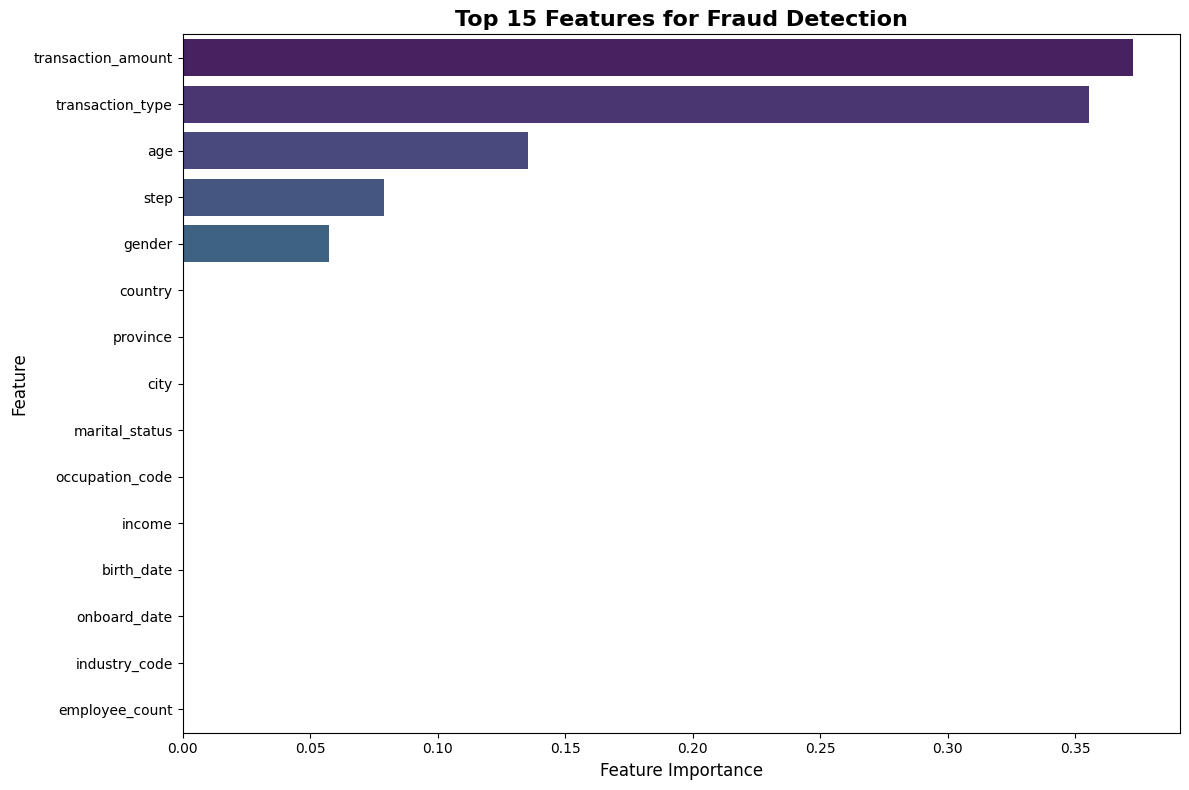


✓ Feature importances saved to 'feature_importances.csv'


In [10]:
# 6. Visualize Feature Importance
# Extract and sort feature importances
importances = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 15 Most Important Features:")
print(importances.head(15).to_string(index=False))

# Create bar plot
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=importances.head(15), palette='viridis')
plt.title('Top 15 Features for Fraud Detection', fontsize=16, fontweight='bold')
plt.xlabel('Feature Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

# Save feature importances to CSV for later reference
importances.to_csv('feature_importances.csv', index=False)
print("\n✓ Feature importances saved to 'feature_importances.csv'")

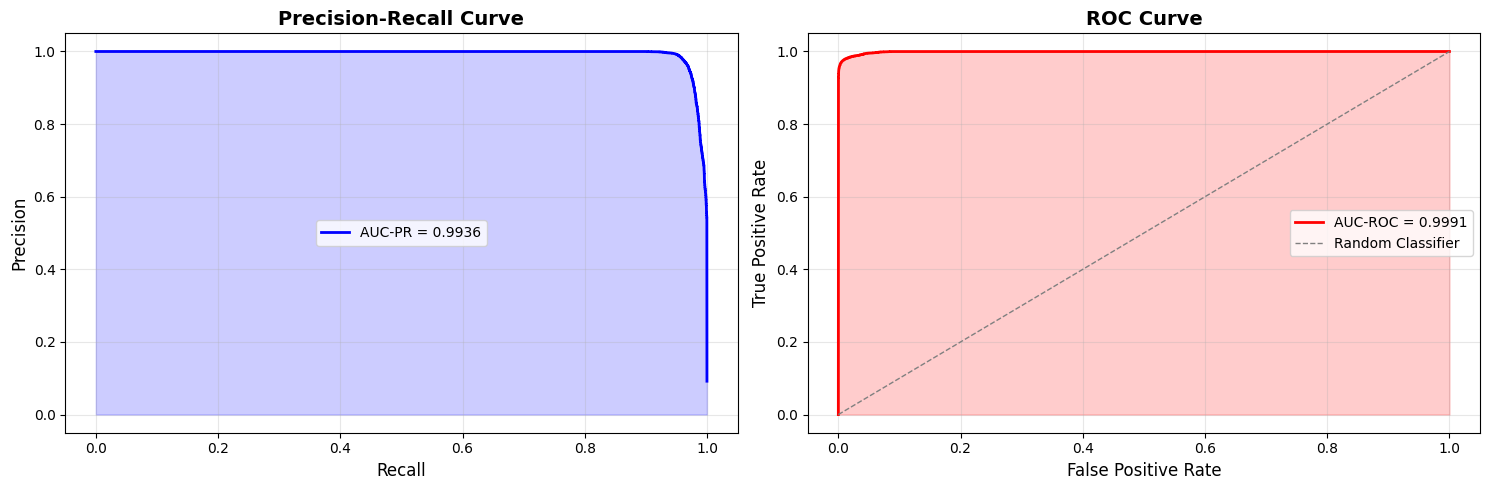


📊 AUC-PR (Primary Metric): 0.9936
📊 AUC-ROC: 0.9991


In [11]:
# 7. Visualize Precision-Recall Curve
from sklearn.metrics import precision_recall_curve, roc_curve

# Calculate precision-recall curve
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_probs)
fpr, tpr, roc_thresholds = roc_curve(y_test, y_probs)

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Precision-Recall Curve
ax1.plot(recall, precision, color='blue', lw=2, label=f'AUC-PR = {aucpr:.4f}')
ax1.fill_between(recall, precision, alpha=0.2, color='blue')
ax1.set_xlabel('Recall', fontsize=12)
ax1.set_ylabel('Precision', fontsize=12)
ax1.set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3)

# ROC Curve
ax2.plot(fpr, tpr, color='red', lw=2, label=f'AUC-ROC = {auc_roc:.4f}')
ax2.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')
ax2.fill_between(fpr, tpr, alpha=0.2, color='red')
ax2.set_xlabel('False Positive Rate', fontsize=12)
ax2.set_ylabel('True Positive Rate', fontsize=12)
ax2.set_title('ROC Curve', fontsize=14, fontweight='bold')
ax2.legend(loc='best', fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📊 AUC-PR (Primary Metric): {aucpr:.4f}")
print(f"📊 AUC-ROC: {auc_roc:.4f}")

In [12]:
# 8. Save the trained model
import pickle

# Save the model
model_filename = 'fraud_detection_rf_model.pkl'
with open(model_filename, 'wb') as f:
    pickle.dump(rf, f)

print(f"✓ Model saved to '{model_filename}'")
print(f"\nModel Details:")
print(f"  - Number of trees: {rf.n_estimators}")
print(f"  - Max depth: {rf.max_depth}")
print(f"  - Number of features: {rf.n_features_in_}")
print(f"  - Number of classes: {rf.n_classes_}")
print(f"\nTo load the model later:")
print(f"  with open('{model_filename}', 'rb') as f:")
print(f"      loaded_model = pickle.load(f)")

✓ Model saved to 'fraud_detection_rf_model.pkl'

Model Details:
  - Number of trees: 100
  - Max depth: 10
  - Number of features: 17
  - Number of classes: 2

To load the model later:
  with open('fraud_detection_rf_model.pkl', 'rb') as f:
      loaded_model = pickle.load(f)


In [13]:
# 9. Analyze Sample Predictions
# Create a comparison dataframe
results_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred,
    'Fraud_Probability': y_probs
})

# Show some high-confidence fraud predictions
print("="*80)
print("HIGH CONFIDENCE FRAUD PREDICTIONS (Top 10)")
print("="*80)
high_fraud = results_df.sort_values('Fraud_Probability', ascending=False).head(10)
print(high_fraud.to_string(index=False))

# Show some examples where model was wrong
print("\n" + "="*80)
print("FALSE POSITIVES (Predicted Fraud but Actually Normal)")
print("="*80)
false_positives = results_df[(results_df['Actual'] == 0) & (results_df['Predicted'] == 1)]
print(f"Total False Positives: {len(false_positives)}")
if len(false_positives) > 0:
    print(false_positives.head(5).to_string(index=False))

print("\n" + "="*80)
print("FALSE NEGATIVES (Predicted Normal but Actually Fraud)")
print("="*80)
false_negatives = results_df[(results_df['Actual'] == 1) & (results_df['Predicted'] == 0)]
print(f"Total False Negatives: {len(false_negatives)}")
if len(false_negatives) > 0:
    print(false_negatives.head(5).to_string(index=False))

HIGH CONFIDENCE FRAUD PREDICTIONS (Top 10)
 Actual  Predicted  Fraud_Probability
      1          1                1.0
      1          1                1.0
      1          1                1.0
      1          1                1.0
      1          1                1.0
      1          1                1.0
      1          1                1.0
      1          1                1.0
      1          1                1.0
      1          1                1.0

FALSE POSITIVES (Predicted Fraud but Actually Normal)
Total False Positives: 791
 Actual  Predicted  Fraud_Probability
      0          1           0.555469
      0          1           0.689871
      0          1           0.962732
      0          1           0.516175
      0          1           0.531921

FALSE NEGATIVES (Predicted Normal but Actually Fraud)
Total False Negatives: 306
 Actual  Predicted  Fraud_Probability
      1          0           0.473596
      1          0           0.058765
      1          0           0.26

In [ ]:
# 1. Generate Transaction IDs for BankSim (since it doesn't have them)
banksim_df['transaction_id'] = ['BS_' + str(i) for i in range(len(banksim_df))]

# 2. Map BankSim categories to your Master list
mapping = {
    'es_transportation': 'TRAVEL',
    'es_food': 'FOOD_DINING',
    'es_wellness': 'HEALTHCARE',
    # ... add the rest
}
banksim_df['master_category'] = banksim_df['category'].map(mapping)

# 3. Create a common schema
# Columns: [transaction_id, customer_id, amount, category, timestamp, city, label]
# For BankSim, 'step' is your timestamp (Day 0, 1, 2...). 
# For Scotiabank, you'll convert 'transaction_datetime' to a numerical step.

master_pool = pd.concat([
    banksim_df[['transaction_id', 'customer', 'amount', 'master_category', 'step', 'zipcodeOri', 'fraud']],
    # Add Scotiabank card.csv here once mapped
])

In [56]:
# Load and inspect card.csv to see transaction categories
card_df = pd.read_csv('data/card.csv')

# Print head of all columns
print(f"\n" + "="*80)
print("Head of card.csv:")
print("="*80)
print(card_df.head())

print(f"\n" + "="*80)
print("Data Info:")
print("="*80)
print(card_df.info())



The history saving thread hit an unexpected error (OperationalError('disk I/O error')).History will not be written to the database.

Head of card.csv:
       transaction_id      customer_id  amount_cad debit_credit  \
0  CARD24110131109543  SYNID0102450742       13.35            D   
1  CARD24110136178868  SYNID0105586872        6.05            D   
2  CARD24110173783589  SYNID0107901560       81.40            C   
3  CARD24110142566805  SYNID0107237475        3.20            D   
4  CARD24110150346602  SYNID0109982946      356.03            D   

  transaction_datetime merchant_category  ecommerce_ind country province  \
0  2024-11-01 00:00:06              5812              1      CA       ON   
1  2024-11-01 00:00:17              5968              1     NaN      NaN   
2  2024-11-01 00:00:37              4816              0      CA       BC   
3  2024-11-01 00:00:41              5814              0      CA       ON   
4  2024-11-01 00:00:51                 0              0      CA   

In [ ]:
industry_df = pd.read_csv('data/kyc_industry_codes.csv')
print(industry_df.columns.tolist())
print(industry_df['industry'].value_counts().tail())
print('\n')
print(industry_df['industry_code'].value_counts().tail())

['industry_code', 'industry']
industry
Other Financial Intermediaries n.e.c.                    1
Other Institutional Health and Social Services n.e.c.    1
Health Rehabilitation Clinics                            1
Hotels and Motor Hotels                                  1
Tour Wholesalers and Operators                           1
Name: count, dtype: int64


industry_code
7499    1
8629    1
8633    1
9111    1
9962    1
Name: count, dtype: int64


In [52]:
occupation_df = pd.read_csv('data/kyc_industry_codes.csv')
print(occupation_df.columns.tolist())
print(occupation_df['industry'].value_counts().tail())
print('\n')
print(occupation_df['industry_code'].value_counts().tail())

['industry_code', 'industry']
industry
Other Financial Intermediaries n.e.c.                    1
Other Institutional Health and Social Services n.e.c.    1
Health Rehabilitation Clinics                            1
Hotels and Motor Hotels                                  1
Tour Wholesalers and Operators                           1
Name: count, dtype: int64


industry_code
7499    1
8629    1
8633    1
9111    1
9962    1
Name: count, dtype: int64


In [54]:
code = card_df['merchant_category'][0]
print(code)
print(occupation_df['industry_code'].head())
occupation_df[occupation_df['industry_code'] == code]

5812
0    112
1    119
2    139
3    141
4    171
Name: industry_code, dtype: int64


,industry_code,industry


In [57]:
# Count unique customers in banksim dataset
unique_customers = banksim_df['customer'].nunique()
print(f"Number of unique customers in BankSim dataset: {unique_customers}")
print(f"Total transactions: {len(banksim_df)}")
print(f"Average transactions per customer: {len(banksim_df) / unique_customers:.2f}")

Number of unique customers in BankSim dataset: 4112
Total transactions: 594643
Average transactions per customer: 144.61


# Preparing for random forest

In [6]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

def build_master_transaction_pool(banksim_path, card_df, abm_df, cheque_df, eft_df, emt_df, westernunion_df, wire_df):
    labels_df = pd.read_csv('data/labels.csv.gz')
    
    # 1. PREP BANKSIM
    bs = pd.read_csv(banksim_path)
    bs.columns = bs.columns.str.replace("'", "")
    for col in bs.select_dtypes('object'):
        bs[col] = bs[col].str.replace("'", "")
    
    start_date = datetime(year=2024, month=11, day=1)
    bs['transaction_datetime'] = bs['step'].apply(lambda x: start_date + timedelta(days=x))
    
    # Updated mapping to specific Industry Names
    cat_map = {
        'es_transportation': 'Taxicab Industry', 'es_food': 'Food (Groceries) Stores',
        'es_health': 'Offices of Physicians, General Practice', 
        'es_wellnessandbeauty': 'Combination Barber and Beauty shops',
        'es_fashion': "Women's Clothing Stores", 'es_barsandrestaurants': 'Restaurants, Licensed',
        'es_hyper': 'General Stores', 'es_sportsandtoys': 'Sporting Goods Stores',
        'es_tech': 'Computer Services', 'es_home': 'Other Household Furnishings Stores',
        'es_hotelservices': 'Hotels and Motor Hotels', 'es_otherservices': 'Other Services n.e.c.',
        'es_contents': 'Other Publishing Industries', 'es_travel': 'Tour Wholesalers and Operators', 
        'es_leisure': 'Other Amusement and Recreational Services n.e.c.'
    }
    
    bs_master = pd.DataFrame({
        'transaction_id': [f"BS_{i}" for i in range(len(bs))],
        'customer_id': bs['customer'],
        'amount_cad': bs['amount'] * 1.62,
        'debit_credit': 'debit',
        'transaction_datetime': bs['transaction_datetime'],
        'merchant_category': bs['category'].map(cat_map),
        'ecommerce_ind': np.where(bs['category'].isin(['es_tech', 'es_contents']), 1, 0),
        'cash_indicator': 0, 
        'country': 'Canada', 'province': 'Ontario', 'city': 'Toronto', # BankSim is all Zip 28007
        'is_fraud': bs['fraud'],
        'source_dataset': 'banksim'
    })

    # 2. PREP SCOTIABANK (CARD)
    card_master = card_df.copy()
    card_master['source_dataset'] = 'scotia_card'
    card_master['cash_indicator'] = 0
    card_master = card_master.merge(labels_df[['customer_id', 'label']], on='customer_id', how='left')
    card_master['is_fraud'] = card_master['label'].fillna(-1).astype(int)
    card_master.drop(columns=['label'], inplace=True)

    # 3. PREP SCOTIABANK (ABM)
    abm_master = abm_df.copy()
    abm_master['merchant_category'] = 'ATM_WITHDRAWAL'
    abm_master['ecommerce_ind'] = 0
    abm_master['source_dataset'] = 'scotia_abm'
    # ABM is almost always a cash transaction
    abm_master['cash_indicator'] = 1 
    abm_master = abm_master.merge(labels_df[['customer_id', 'label']], on='customer_id', how='left')
    abm_master['is_fraud'] = abm_master['label'].fillna(-1).astype(int)
    abm_master.drop(columns=['label'], inplace=True)

    # 4. PREP OTHERS (Separate categories for better Graph Hubs)
    # We assign unique categories so the GAT can learn different risk weights for Wires vs EMTs
    cheque_df['merchant_category'] = 'CHEQUE'
    eft_df['merchant_category'] = 'EFT_TRANSFER'
    emt_df['merchant_category'] = 'INTERAC_EMT'
    westernunion_df['merchant_category'] = 'WESTERN_UNION'
    wire_df['merchant_category'] = 'WIRE_TRANSFER'

    others = pd.concat([cheque_df, eft_df, emt_df, westernunion_df, wire_df], axis=0)
    others['ecommerce_ind'] = 0
    others['cash_indicator'] = 0
    others['country'], others['province'], others['city'] = 'Canada', 'N/A', 'N/A'
    others['source_dataset'] = 'scotia_transfer'
    
    others = others.merge(labels_df[['customer_id', 'label']], on='customer_id', how='left')
    others['is_fraud'] = others['label'].fillna(-1).astype(int)
    others.drop(columns=['label'], inplace=True)

    # 5. THE GRAND MERGE
    master_pool = pd.concat([bs_master, card_master, abm_master, others], axis=0, ignore_index=True)
    
    return master_pool

In [ ]:
# Load optional datasets (if files are missing, use empty frames with card_df schema)
def load_or_empty(path, columns):
    return pd.read_csv(path) if os.path.exists(path) else pd.DataFrame(columns=columns)

base_cols = card_df.columns.tolist()

abm_df = load_or_empty('data/abm.csv', base_cols)
cheque_df = load_or_empty('data/cheque.csv', base_cols)
eft_df = load_or_empty('data/eft.csv', base_cols)
emt_df = load_or_empty('data/emt.csv', base_cols)
westernunion_df = load_or_empty('data/westernunion.csv', base_cols)
wire_df = load_or_empty('data/wire.csv', base_cols)

# Build master transaction pool and save to parquet
master_transaction_pool = build_master_transaction_pool(
    'banksim/bs140513_032310.csv',
    card_df,
    abm_df,
    cheque_df,
    eft_df,
    emt_df,
    westernunion_df,
    wire_df
)

master_transaction_pool.to_parquet('master_transaction_pool.parquet', index=False)
print(f"Saved: master_transaction_pool.parquet ({len(master_transaction_pool)} rows)")

In [8]:
import os
# Load optional datasets (if files are missing, use empty frames with card_df schema)
def load_or_empty(path, columns):
    return pd.read_csv(path) if os.path.exists(path) else pd.DataFrame(columns=columns)

base_cols = card_df.columns.tolist()

abm_df = load_or_empty('data/abm.csv.gz', base_cols)
cheque_df = load_or_empty('data/cheque.csv.gz', base_cols)
eft_df = load_or_empty('data/eft.csv.gz', base_cols)
emt_df = load_or_empty('data/emt.csv.gz', base_cols)
westernunion_df = load_or_empty('data/westernunion.csv.gz', base_cols)
wire_df = load_or_empty('data/wire.csv.gz', base_cols)

# Build master transaction pool and save to parquet
master_transaction_pool = build_master_transaction_pool(
    'banksim/bs140513_032310.csv.gz',
    card_df,
    abm_df,
    cheque_df,
    eft_df,
    emt_df,
    westernunion_df,
    wire_df
)

master_transaction_pool.to_csv('master_transaction_pool.csv.gz', index=False, compression='gzip')
print(f"Saved: master_transaction_pool.csv.gz ({len(master_transaction_pool)} rows)")

Saved: master_transaction_pool.csv.gz (6497976 rows)


In [9]:
# Validate master_transaction_pool format
expected_cols = [
    'transaction_id', 'customer_id', 'amount_cad', 'debit_credit',
    'transaction_datetime', 'merchant_category', 'ecommerce_ind',
    'cash_indicator', 'country', 'province', 'city', 'is_fraud', 'source_dataset'
]

missing = [c for c in expected_cols if c not in master_transaction_pool.columns]
extra = [c for c in master_transaction_pool.columns if c not in expected_cols]

print("Format Check:")
print(f"  Rows: {len(master_transaction_pool)}")
print(f"  Columns: {len(master_transaction_pool.columns)}")
print(f"  Missing columns: {missing}")
print(f"  Extra columns: {extra}")

# Check dtypes for key fields
print("\nKey dtypes:")
print(master_transaction_pool[[
    'amount_cad', 'ecommerce_ind', 'cash_indicator', 'is_fraud'
]].dtypes)

# Quick null summary for required columns
print("\nNull counts for required columns:")
print(master_transaction_pool[expected_cols].isna().sum())

# Preview
print("\nSample rows:")
print(master_transaction_pool.head())

Format Check:
  Rows: 6497976
  Columns: 13
  Missing columns: []
  Extra columns: []

Key dtypes:
amount_cad        float64
ecommerce_ind       int64
cash_indicator      int64
is_fraud            int64
dtype: object

Null counts for required columns:
transaction_id               0
customer_id                  0
amount_cad                   0
debit_credit                 0
transaction_datetime         0
merchant_category            0
ecommerce_ind                0
cash_indicator               0
country                 622371
province                702760
city                    534447
is_fraud                     0
source_dataset               0
dtype: int64

Sample rows:
  transaction_id  customer_id  amount_cad debit_credit transaction_datetime  \
0           BS_0  C1093826151      7.3710        debit  2024-11-01 00:00:00   
1           BS_1   C352968107     64.2816        debit  2024-11-01 00:00:00   
2           BS_2  C2054744914     43.5618        debit  2024-11-01 00:00:00   
3 

In [2]:
# Load master_pool from the saved file (FIX: specify dtypes to avoid mixed type warning)
import pandas as pd

# Define expected dtypes for all columns
dtype_spec = {
    'transaction_id': str,
    'customer_id': str,
    'amount_cad': float,
    'debit_credit': str,
    'merchant_category': str,
    'ecommerce_ind': int,
    'cash_indicator': int,
    'country': str,
    'province': str,      # Column 9 - explicitly set as string
    'city': str,          # Column 10 - explicitly set as string
    'is_fraud': int,
    'source_dataset': str
}

# Load with specified dtypes to avoid mixed type warnings
master_pool = pd.read_csv(
    'master_transaction_pool.csv.gz', 
    compression='gzip',
    dtype=dtype_spec,
    parse_dates=['transaction_datetime']  # Parse datetime column separately
)

print(f"✓ Loaded master_transaction_pool successfully!")
print(f"  Shape: {master_pool.shape}")
print(f"  Columns: {master_pool.columns.tolist()}")
print(f"\nData types:")
print(master_pool.dtypes)
print(f"\nFirst few rows:")
print(master_pool.head())

✓ Loaded master_transaction_pool successfully!
  Shape: (6497976, 16)
  Columns: ['transaction_id', 'customer_id', 'amount_cad', 'debit_credit', 'transaction_datetime', 'merchant_category', 'ecommerce_ind', 'cash_indicator', 'country', 'province', 'city', 'is_fraud', 'source_dataset', 'cust_idx', 'cat_idx', 'city_idx']

Data types:
transaction_id           object
customer_id              object
amount_cad              float64
debit_credit             object
transaction_datetime     object
merchant_category        object
ecommerce_ind             int64
cash_indicator            int64
country                  object
province                 object
city                     object
is_fraud                  int64
source_dataset           object
cust_idx                  int64
cat_idx                   int64
city_idx                  int64
dtype: object

First few rows:
  transaction_id  customer_id  amount_cad debit_credit transaction_datetime  \
0           BS_0  C1093826151      7.3710   

# Graph Attention Network

In [3]:
import torch
from torch_geometric.data import HeteroData
import pandas as pd
import numpy as np

# 1. Clean Cities
master_pool['city'] = master_pool['city'].str.upper().fillna('UNKNOWN')

# 2. Create Mappings (String -> ID)
def get_mapping(series):
    unique_vals = series.unique()
    return {val: i for i, val in enumerate(unique_vals)}, len(unique_vals)

cust_map, num_cust = get_mapping(master_pool['customer_id'])
cat_map, num_cat = get_mapping(master_pool['merchant_category'])
city_map, num_city = get_mapping(master_pool['city'])

# 3. Apply Mappings
master_pool['cust_idx'] = master_pool['customer_id'].map(cust_map)
master_pool['cat_idx'] = master_pool['merchant_category'].map(cat_map)
master_pool['city_idx'] = master_pool['city'].map(city_map)

In [14]:
# Save the master_pool dataframe to CSV
master_pool.to_csv('master_pool.csv.gz', index=False, compression='gzip')
print(f"✓ Saved master_pool to 'master_pool.csv.gz'")
print(f"  Shape: {master_pool.shape}")
print(f"  Compressed file size: ~{master_pool.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

✓ Saved master_pool to 'master_pool.csv.gz'
  Shape: (6497976, 18)
  Compressed file size: ~3678.7 MB


In [4]:
# Build customers_df by merging KYC individuals + small businesses, then add BankSim customers
# Expected columns: ['age', 'income', 'tenure', 'sales', 'emp_count', 'is_biz']

# 1) Load KYC data
kyc_ind = pd.read_csv('data/kyc_individual.csv.gz')
kyc_biz = pd.read_csv('data/kyc_smallbusiness.csv.gz')

# Normalize column names
kyc_ind.columns = kyc_ind.columns.str.lower()
kyc_biz.columns = kyc_biz.columns.str.lower()

# Helper to compute tenure if onboard_date exists
def compute_tenure_days(df, date_col='onboard_date'):
    if date_col in df.columns:
        return (pd.Timestamp('2025-01-31') - pd.to_datetime(df[date_col], errors='coerce')).dt.days
    return pd.Series([np.nan] * len(df))

# 2) Prepare individuals
ind = pd.DataFrame({
    'customer_id': kyc_ind['customer_id'].astype(str),
    'age': kyc_ind.get('age', np.nan),
    'income': kyc_ind.get('income', np.nan),
    'tenure': compute_tenure_days(kyc_ind),
    'sales': 0.0,
    'emp_count': 0.0,
    'is_biz': 0
})

# 3) Prepare small businesses
biz = pd.DataFrame({
    'customer_id': kyc_biz['customer_id'].astype(str),
    'age': np.nan,
    'income': kyc_biz.get('income', np.nan),
    'tenure': compute_tenure_days(kyc_biz),
    'sales': kyc_biz.get('sales', 0.0),
    'emp_count': kyc_biz.get('emp_count', 0.0),
    'is_biz': 1
})

# Medians for imputation
median_income = ind['income'].median()
median_age = ind['age'].median()
median_sales = biz['sales'].median() if 'sales' in biz else 0.0
median_emp = biz['emp_count'].median() if 'emp_count' in biz else 0.0

# Fill missing in KYC
for df in (ind, biz):
    df['income'] = df['income'].fillna(median_income)
    df['age'] = df['age'].fillna(median_age)
    df['tenure'] = df['tenure'].fillna(730)  # 2 years
    df['sales'] = df['sales'].fillna(median_sales)
    df['emp_count'] = df['emp_count'].fillna(median_emp)

# 4) Build BankSim customers with default values
banksim = pd.read_csv('banksim/bs140513_032310.csv.gz', usecols=['customer', 'age'])
banksim['customer'] = banksim['customer'].astype(str)

# Map BankSim age categories to midpoints
age_map = {
    '0': 18,   # <=18
    '1': 22,   # 19-25
    '2': 30,   # 26-35
    '3': 40,   # 36-45
    '4': 50,   # 46-55
    '5': 60,   # 56-65
    '6': 70,   # >65
    'U': median_age
}
banksim['age_num'] = banksim['age'].astype(str).map(age_map).fillna(median_age)

# Use BankSim customers present in master_pool
banksim_customers = master_pool.loc[master_pool['source_dataset'] == 'banksim', 'customer_id'].astype(str).unique()
banksim_age = banksim.drop_duplicates('customer').set_index('customer')['age_num']

banksim_df = pd.DataFrame({
    'customer_id': banksim_customers,
    'age': [banksim_age.get(cid, median_age) for cid in banksim_customers],
    'income': median_income,
    'tenure': 730,
    'sales': 0.0,
    'emp_count': 0.0,
    'is_biz': 0
})

# 5) Combine all customers
customers_df = pd.concat([ind, biz, banksim_df], axis=0, ignore_index=True)

# Deduplicate and align to cust_map ordering
customers_df['cust_idx'] = customers_df['customer_id'].map(cust_map)
customers_df = customers_df.dropna(subset=['cust_idx'])
customers_df = customers_df.sort_values('cust_idx').reset_index(drop=True)

# Final cleanup
customers_df[['age', 'income', 'tenure', 'sales', 'emp_count', 'is_biz']] = customers_df[
    ['age', 'income', 'tenure', 'sales', 'emp_count', 'is_biz']
].astype(float)

print(f"customers_df built: {customers_df.shape}")
print(customers_df.head())

/usr/local/lib/python3.10/dist-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


customers_df built: (65522, 8)
   customer_id  age   income  tenure  sales  emp_count  is_biz  cust_idx
0  C1093826151  NaN  35974.0   730.0    0.0        0.0     0.0         0
1   C352968107  NaN  35974.0   730.0    0.0        0.0     0.0         1
2  C2054744914  NaN  35974.0   730.0    0.0        0.0     0.0         2
3  C1760612790  NaN  35974.0   730.0    0.0        0.0     0.0         3
4   C757503768  NaN  35974.0   730.0    0.0        0.0     0.0         4


In [5]:
# Fix KYC individual ages from birth_date
kyc_ind['birth_date'] = pd.to_datetime(kyc_ind['birth_date'], errors='coerce')
ind['age'] = (pd.Timestamp('2025-01-31') - kyc_ind['birth_date']).dt.days / 365.25

# Recompute median_age after fixing
median_age = ind['age'].median()

# Fix BankSim age parsing (strip quotes) and map to numbers
banksim['age'] = banksim['age'].astype(str).str.strip("'")
banksim['age_num'] = banksim['age'].map(age_map).fillna(median_age)
banksim_age = banksim.drop_duplicates('customer').set_index('customer')['age_num']

banksim_df['age'] = [banksim_age.get(cid, median_age) for cid in banksim_customers]

# Rebuild customers_df ages and fill remaining nulls
customers_df['age'] = customers_df['customer_id'].map(
    pd.concat([ind.set_index('customer_id')['age'],
               banksim_df.set_index('customer_id')['age']])
)
customers_df['age'] = customers_df['age'].fillna(median_age)


In [7]:
customers_df.head()

,customer_id,age,income,tenure,sales,emp_count,is_biz,cust_idx
0,C1093826151,46.63655,35974.0,730.0,0.0,0.0,0.0,0
1,C352968107,46.63655,35974.0,730.0,0.0,0.0,0.0,1
2,C2054744914,46.63655,35974.0,730.0,0.0,0.0,0.0,2
3,C1760612790,46.63655,35974.0,730.0,0.0,0.0,0.0,3
4,C757503768,46.63655,35974.0,730.0,0.0,0.0,0.0,4


In [6]:
# Ensure data is sorted by customer and time! This is critical.
# First, convert transaction_datetime to datetime (in case it's still string)
# Use format='mixed' to handle different datetime formats
master_pool['transaction_datetime'] = pd.to_datetime(master_pool['transaction_datetime'], format='mixed')

master_pool = master_pool.sort_values(['customer_id', 'transaction_datetime'])

# 1. Calculate Time Delta (in minutes)
# Difference between current and previous transaction for that customer
master_pool['time_delta'] = master_pool.groupby('customer_id')['transaction_datetime'].diff().dt.total_seconds() / 60
master_pool['time_delta'] = master_pool['time_delta'].fillna(0) # First transaction has no delta

# 2. Calculate 24h Velocity
# We use a rolling window of 24 hours ('24H') 
# 'on' specifies the time column, and we count the number of transaction_ids
master_pool['velocity_24h'] = (
    master_pool.groupby('customer_id')
    .rolling(window='24H', on='transaction_datetime')['transaction_id']
    .count()
    .values # extract values to align back to original dataframe
)

# Transaction Features
# [log_amount, ecommerce_ind, cash_indicator, velocity_24h, time_delta]
x_trans = torch.tensor(np.stack([
    np.log1p(master_pool['amount_cad']),
    master_pool['ecommerce_ind'],
    master_pool['cash_indicator'],
    # You'll need to calculate velocity/time_delta during your Day 3 processing
    master_pool['velocity_24h'], 
    master_pool['time_delta']
], axis=1), dtype=torch.float)

# Customer Features (Zero-padded Individual + Business)
# [Age, Income, Tenure, Sales, Employee_Count, Is_Business]
# (Assume you merged kyc_ind and kyc_biz into a 'customers_df')
x_cust = torch.tensor(customers_df[['age', 'income', 'tenure', 'sales', 'emp_count', 'is_biz']].values, dtype=torch.float)

# Hub Features (Start as Identity or simple constants)
x_cat = torch.eye(num_cat) # One-hot encoding for small number of categories
x_city = torch.eye(num_city)

/tmp/ipykernel_141275/4286420922.py:17: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  master_pool.groupby('customer_id')
/tmp/ipykernel_141275/4286420922.py:17: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  master_pool.groupby('customer_id')


In [18]:
import torch.nn as nn

def masked_weighted_loss(y_pred, y_true, pos_weight):
    """
    Masked weighted binary cross entropy loss for class imbalance
    Args:
        y_pred: predictions (logits)
        y_true: true labels (may contain -1 for unlabeled)
        pos_weight: weight for positive class
    """
    # Create a mask where label is NOT -1
    mask = (y_true != -1)
    
    # If no labeled nodes in this batch, return 0 loss
    if mask.sum() == 0:
        return torch.tensor(0.0, requires_grad=True).to(y_pred.device)
    
    # Filter only the labeled nodes
    labeled_pred = y_pred[mask]
    labeled_true = y_true[mask].float()
    
    # Binary Cross Entropy with Logits with pos_weight for imbalance
    return nn.BCEWithLogitsLoss(pos_weight=pos_weight)(labeled_pred, labeled_true)

In [8]:
data = HeteroData()

# Add Nodes
data['customer'].x = x_cust
data['transaction'].x = x_trans
data['category'].x = x_cat
data['city'].x = x_city

# Add Edges (Source, Target)
data['transaction', 'to', 'customer'].edge_index = torch.stack([
    torch.tensor(master_pool.index, dtype=torch.long),
    torch.tensor(master_pool['cust_idx'].values, dtype=torch.long)
])

data['transaction', 'at', 'category'].edge_index = torch.stack([
    torch.tensor(master_pool.index, dtype=torch.long),
    torch.tensor(master_pool['cat_idx'].values, dtype=torch.long)
])

data['transaction', 'in', 'city'].edge_index = torch.stack([
    torch.tensor(master_pool.index, dtype=torch.long),
    torch.tensor(master_pool['city_idx'].values, dtype=torch.long)
])

# PyG requires reverse edges for bidirectional flow
import torch_geometric.transforms as T
data = T.ToUndirected()(data)

In [9]:
# Add labels and masks for customer nodes
# For this example, we'll create labels based on whether a customer has any fraudulent transactions

# Create customer-level labels (1 if customer has any fraud, 0 otherwise)
customer_fraud = master_pool.groupby('cust_idx')['is_fraud'].max().values
data['customer'].y = torch.tensor(customer_fraud, dtype=torch.float)

# Create train/val/test masks (80/10/10 split)
num_customers = num_cust
perm = torch.randperm(num_customers)

train_size = int(0.8 * num_customers)
val_size = int(0.1 * num_customers)

train_mask = torch.zeros(num_customers, dtype=torch.bool)
val_mask = torch.zeros(num_customers, dtype=torch.bool)
test_mask = torch.zeros(num_customers, dtype=torch.bool)

train_mask[perm[:train_size]] = True
val_mask[perm[train_size:train_size + val_size]] = True
test_mask[perm[train_size + val_size:]] = True

data['customer'].train_mask = train_mask
data['customer'].val_mask = val_mask
data['customer'].test_mask = test_mask

print(f"Customer nodes: {num_customers}")
print(f"Train: {train_mask.sum()}, Val: {val_mask.sum()}, Test: {test_mask.sum()}")
print(f"Fraud rate: {customer_fraud.mean():.4f}")

Customer nodes: 65522
Train: 52417, Val: 6552, Test: 6553
Fraud rate: -0.8992


In [31]:
import torch.nn.functional as F
import torch
from torch_geometric.nn import GATv2Conv, SAGEConv, HeteroConv, Linear

# class FraudGAT(torch.nn.Module):
#     def __init__(self, hidden_channels, out_channels, num_heads):
#         super().__init__()
        
#         # Use SAGEConv which is more robust for mini-batch sampling
#         # Layer 1: Aggregate all info to transactions
#         self.conv1 = HeteroConv({
#             ('customer', 'rev_to', 'transaction'): SAGEConv((-1, -1), hidden_channels),
#             ('category', 'rev_at', 'transaction'): SAGEConv((-1, -1), hidden_channels),
#             ('city', 'rev_in', 'transaction'): SAGEConv((-1, -1), hidden_channels),
#         }, aggr='mean')
        
#         # Layer 2: Aggregate transactions to customers
#         self.conv2 = HeteroConv({
#             ('transaction', 'to', 'customer'): SAGEConv((-1, -1), hidden_channels),
#         }, aggr='mean')

#         self.lin = Linear(hidden_channels, out_channels)

#     def forward(self, x_dict, edge_index_dict):
#         # Layer 1: Aggregate to transactions
#         x_dict = self.conv1(x_dict, edge_index_dict)
#         x_dict = {key: F.relu(x) for key, x in x_dict.items()}
        
#         # Layer 2: Aggregate to customers
#         x_dict = self.conv2(x_dict, edge_index_dict)
#         x_dict = {key: F.relu(x) for key, x in x_dict.items()}
        
#         # Output prediction
#         return self.lin(x_dict['customer'])

class FraudGAT(torch.nn.Module):
    def __init__(self, hidden_channels, out_channels, num_heads):
        super().__init__()
        # Use GATv2 for dynamic attention weights
        self.conv1 = HeteroConv({
            ('customer', 'rev_to', 'transaction'): GATv2Conv((-1, -1), hidden_channels, heads=num_heads, add_self_loops=False),
            ('category', 'rev_at', 'transaction'): GATv2Conv((-1, -1), hidden_channels, heads=num_heads, add_self_loops=False),
            ('city', 'rev_in', 'transaction'): GATv2Conv((-1, -1), hidden_channels, heads=num_heads, add_self_loops=False),
        }, aggr='sum')
        
        self.conv2 = HeteroConv({
            ('transaction', 'to', 'customer'): GATv2Conv((-1, -1), hidden_channels, heads=num_heads, add_self_loops=False),
        }, aggr='sum')

        # Final projection to 1 output (fraud probability)
        # Note: we multiply by num_heads because GATv2 concatenates head outputs
        self.lin = Linear(hidden_channels * num_heads, out_channels)

    def forward(self, x_dict, edge_index_dict):
        # Layer 1: Update Transactions using info from Customer/Category/City
        # We keep a copy of the original x_dict to preserve nodes not updated here
        x_dict_out = self.conv1(x_dict, edge_index_dict)
        x_dict_out = {key: F.elu(x) for key, x in x_dict_out.items()}
        
        # Crucial: Merge the updated transaction features back with the original dict
        # so Layer 2 can find 'customer' nodes to map TO.
        for key in x_dict:
            if key not in x_dict_out:
                x_dict_out[key] = x_dict[key]

        # Layer 2: Update Customers using info from Transactions
        x_dict_final = self.conv2(x_dict_out, edge_index_dict)
        
        # Final ELU and Linear projection
        return self.lin(F.elu(x_dict_final['customer']))

In [28]:
# Create NeighborLoader for mini-batch training to avoid GPU OOM
from torch_geometric.loader import NeighborLoader

# Configuration for neighbor sampling
# Use smaller batch size and fewer neighbors to fit in GPU memory
BATCH_SIZE = 512  # Smaller batch size to reduce memory usage
NUM_NEIGHBORS = [10, 5]  # Sample 10 neighbors in first hop, 5 in second hop

print("Creating NeighborLoaders for mini-batch training...")
print(f"Batch size: {BATCH_SIZE}")
print(f"Neighbor sampling: {NUM_NEIGHBORS}")

train_loader = NeighborLoader(
    data,
    num_neighbors=NUM_NEIGHBORS,
    batch_size=BATCH_SIZE,
    input_nodes=('customer', data['customer'].train_mask),
    shuffle=True,
    num_workers=0  # CPU-based sampling
)

val_loader = NeighborLoader(
    data,
    num_neighbors=NUM_NEIGHBORS,
    batch_size=BATCH_SIZE,
    input_nodes=('customer', data['customer'].val_mask),
    shuffle=False,
    num_workers=0
)

print(f"✓ Train loader created: ~{len(train_loader)} batches")
print(f"✓ Val loader created: ~{len(val_loader)} batches")

Creating NeighborLoaders for mini-batch training...
Batch size: 512
Neighbor sampling: [10, 5]


/student/minalex/.local/lib/python3.10/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(


✓ Train loader created: ~103 batches
✓ Val loader created: ~13 batches


In [40]:
# Create model on GPU (smaller size to fit in memory)
model = FraudGAT(hidden_channels=32, out_channels=1, num_heads=2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Keep data on CPU - NeighborLoader will move batches to GPU as needed
# Calculate pos_weight for class imbalance
initial_train_mask = data['customer'].train_mask.clone()
train_labels = data['customer'].y[initial_train_mask]
labeled_mask = train_labels != -1
fraud_count = (train_labels[labeled_mask] == 1).sum()
legit_count = (train_labels[labeled_mask] == 0).sum()
pos_weight = (legit_count / fraud_count).to(device)

print(f"Initial class distribution - Fraud: {fraud_count}, Legit: {legit_count}, Pos Weight: {pos_weight:.2f}")
print(f"Model: hidden_channels=32, num_heads=2")

# Training configuration
num_epochs = 50
FRAUD_THRESHOLD = 0.98  # High confidence for fraud
LEGIT_THRESHOLD = 0.02  # High confidence for legit
WARMUP_EPOCHS = 20     # Epochs before using pseudo-labels

# Track pseudo-labeling statistics
total_pseudo_labeled = 0

print("\nStarting training with NeighborLoader...")
for epoch in tqdm(range(num_epochs), desc="Training"):
    model.train()
    epoch_loss = 0
    num_batches = 0
    
    # Training loop with mini-batches from NeighborLoader
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        
        # Forward pass on batch subgraph
        out = model(batch.x_dict, batch.edge_index_dict)
        
        # Extract predictions for input customer nodes only (not sampled neighbors)
        batch_size = batch['customer'].batch_size  # Number of input customer nodes
        customer_out = out.squeeze()[:batch_size]  # Take only input nodes
        customer_y = batch['customer'].y[:batch_size]
        
        # Calculate loss on labeled nodes in batch
        labeled_mask = customer_y != -1
        if labeled_mask.sum() > 0:
            loss = masked_weighted_loss(customer_out[labeled_mask], customer_y[labeled_mask], pos_weight)
            
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            num_batches += 1
    
    avg_loss = epoch_loss / num_batches if num_batches > 0 else 0
    
    # Pseudo-labeling phase (after warmup) - inference on full graph
    # Do this less frequently to save time (every 5 epochs)
    if epoch >= WARMUP_EPOCHS and epoch % 5 == 0:
        model.eval()
        with torch.no_grad():
            # Use NeighborLoader to do inference in batches (avoids OOM)
            all_probs = torch.zeros(data['customer'].num_nodes)
            all_indices = torch.zeros(data['customer'].num_nodes, dtype=torch.long)
            
            # Create a loader for all customer nodes
            inference_loader = NeighborLoader(
                data,
                num_neighbors=NUM_NEIGHBORS,
                batch_size=BATCH_SIZE * 2,  # Larger batch for inference
                input_nodes=('customer', torch.ones(data['customer'].num_nodes, dtype=torch.bool)),
                shuffle=False,
                num_workers=0
            )
            
            for batch in inference_loader:
                batch = batch.to(device)
                out = model(batch.x_dict, batch.edge_index_dict)
                
                # Get predictions for input nodes only
                batch_size_inf = batch['customer'].batch_size
                customer_out = out.squeeze()[:batch_size_inf]
                probs = torch.sigmoid(customer_out).cpu()
                
                # Store probabilities using node indices
                input_node_ids = batch['customer'].n_id[:batch_size_inf]
                all_probs[input_node_ids] = probs
            
            # Find unlabeled nodes (y == -1)
            unlabeled_mask = (data['customer'].y == -1)
            
            # Identify high-confidence predictions
            high_conf_fraud = (all_probs > FRAUD_THRESHOLD) & unlabeled_mask
            high_conf_legit = (all_probs < LEGIT_THRESHOLD) & unlabeled_mask
            
            # Update labels permanently
            n_fraud = high_conf_fraud.sum().item()
            n_legit = high_conf_legit.sum().item()
            
            if n_fraud > 0 or n_legit > 0:
                # Lock in pseudo-labels
                data['customer'].y[high_conf_fraud] = 1.0
                data['customer'].y[high_conf_legit] = 0.0
                
                total_pseudo_labeled += (n_fraud + n_legit)
                
                tqdm.write(f"  → Pseudo-labeled: {n_fraud} fraud, {n_legit} legit (Total: {total_pseudo_labeled})")
            
            # Clean up
            del inference_loader
            gc.collect()
    
    # Validation every 5 epochs
    if epoch % 5 == 0:
        model.eval()
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                out = model(batch.x_dict, batch.edge_index_dict)
                
                # Get predictions for input nodes only
                batch_size_val = batch['customer'].batch_size
                customer_out = out.squeeze()[:batch_size_val]
                probs = torch.sigmoid(customer_out)
                
                customer_y = batch['customer'].y[:batch_size_val]
                labeled_mask = customer_y != -1
                
                if labeled_mask.sum() > 0:
                    preds = (probs[labeled_mask] > 0.5).float()
                    val_correct += (preds == customer_y[labeled_mask]).sum().item()
                    val_total += labeled_mask.sum().item()
        
        val_acc = val_correct / val_total if val_total > 0 else 0
        tqdm.write(f"Epoch {epoch}: Train Loss={avg_loss:.4f}, Val Acc={val_acc:.4f}")

print(f"\n✓ Training complete! Total pseudo-labeled nodes: {total_pseudo_labeled}")

/tmp/ipykernel_141275/2756772312.py:40: UserWarning: There exist node types ({'city', 'category', 'customer'}) whose representations do not get updated during message passing as they do not occur as destination type in any edge type. This may lead to unexpected behavior.
  self.conv1 = HeteroConv({
/tmp/ipykernel_141275/2756772312.py:46: UserWarning: There exist node types ({'transaction'}) whose representations do not get updated during message passing as they do not occur as destination type in any edge type. This may lead to unexpected behavior.
  self.conv2 = HeteroConv({


Initial class distribution - Fraud: 4763, Legit: 47654, Pos Weight: 10.01
Model: hidden_channels=32, num_heads=2

Starting training with NeighborLoader...


Training:   0%|          | 0/50 [00:00<?, ?it/s]

Training:   2%|▏         | 1/50 [00:01<01:31,  1.86s/it]

Epoch 0: Train Loss=103.7696, Val Acc=0.7782


...

Epoch 40: Train Loss=5.0679, Val Acc=0.9447


Training:  92%|█████████▏| 46/50 [01:11<00:10,  2.66s/it]

Epoch 45: Train Loss=7.4531, Val Acc=0.6085


Training: 100%|██████████| 50/50 [01:16<00:00,  1.53s/it]


✓ Training complete! Total pseudo-labeled nodes: 0


## 📊 Test Set Evaluation

Now let's evaluate the trained model on the held-out test set and generate comprehensive fraud detection metrics.

In [41]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, auc
import numpy as np

# Evaluate on test set
model.eval()
test_preds = []
test_labels = []
test_probs = []

# Create test loader
test_loader = NeighborLoader(
    data,
    num_neighbors=NUM_NEIGHBORS,
    batch_size=BATCH_SIZE * 2,
    input_nodes=('customer', test_mask),
    shuffle=False,
    num_workers=0
)

print("Evaluating on test set...")
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        out = model(batch.x_dict, batch.edge_index_dict)
        
        # Get predictions for input nodes only
        batch_size_test = batch['customer'].batch_size
        customer_out = out.squeeze()[:batch_size_test]
        probs = torch.sigmoid(customer_out).cpu()
        
        customer_y = batch['customer'].y[:batch_size_test].cpu()  # Move to CPU
        labeled_mask = customer_y != -1
        
        if labeled_mask.sum() > 0:
            test_probs.extend(probs[labeled_mask].tolist())
            test_preds.extend((probs[labeled_mask] > 0.5).float().tolist())
            test_labels.extend(customer_y[labeled_mask].tolist())

# Convert to numpy arrays
test_preds = np.array(test_preds)
test_labels = np.array(test_labels)
test_probs = np.array(test_probs)

# Calculate metrics
print("\n" + "="*60)
print("TEST SET RESULTS")
print("="*60)
print(f"\nTotal test samples: {len(test_labels)}")
print(f"Fraud samples: {(test_labels == 1).sum()}")
print(f"Legit samples: {(test_labels == 0).sum()}")

print("\n" + "-"*60)
print("Classification Report:")
print("-"*60)
print(classification_report(test_labels, test_preds, target_names=['Legit', 'Fraud'], digits=4))

# Confusion Matrix
cm = confusion_matrix(test_labels, test_preds)
print("\n" + "-"*60)
print("Confusion Matrix:")
print("-"*60)
print(f"                 Predicted Legit  Predicted Fraud")
print(f"Actual Legit     {cm[0,0]:>15}  {cm[0,1]:>15}")
print(f"Actual Fraud     {cm[1,0]:>15}  {cm[1,1]:>15}")

# ROC-AUC
roc_auc = roc_auc_score(test_labels, test_probs)
print(f"\n{'ROC-AUC Score:':<30} {roc_auc:.4f}")

# Precision-Recall AUC
precision, recall, _ = precision_recall_curve(test_labels, test_probs)
pr_auc = auc(recall, precision)
print(f"{'Precision-Recall AUC:':<30} {pr_auc:.4f}")

# Additional fraud-specific metrics
fraud_recall = cm[1,1] / (cm[1,1] + cm[1,0]) if (cm[1,1] + cm[1,0]) > 0 else 0
fraud_precision = cm[1,1] / (cm[1,1] + cm[0,1]) if (cm[1,1] + cm[0,1]) > 0 else 0
print(f"{'Fraud Detection Rate:':<30} {fraud_recall:.4f} ({cm[1,1]}/{cm[1,1] + cm[1,0]} frauds caught)")
print(f"{'Fraud Precision:':<30} {fraud_precision:.4f} ({cm[1,1]}/{cm[1,1] + cm[0,1]} correct fraud alerts)")
print("="*60)

Evaluating on test set...

TEST SET RESULTS

Total test samples: 6553
Fraud samples: 593
Legit samples: 5960

------------------------------------------------------------
Classification Report:
------------------------------------------------------------
              precision    recall  f1-score   support

       Legit     0.9573    0.9708    0.9640      5960
       Fraud     0.6582    0.5649    0.6080       593

    accuracy                         0.9341      6553
   macro avg     0.8077    0.7679    0.7860      6553
weighted avg     0.9302    0.9341    0.9318      6553


------------------------------------------------------------
Confusion Matrix:
------------------------------------------------------------
                 Predicted Legit  Predicted Fraud
Actual Legit                5786              174
Actual Fraud                 258              335

ROC-AUC Score:                 0.9441
Precision-Recall AUC:          0.7080
Fraud Detection Rate:          0.5649 (335/593 fra

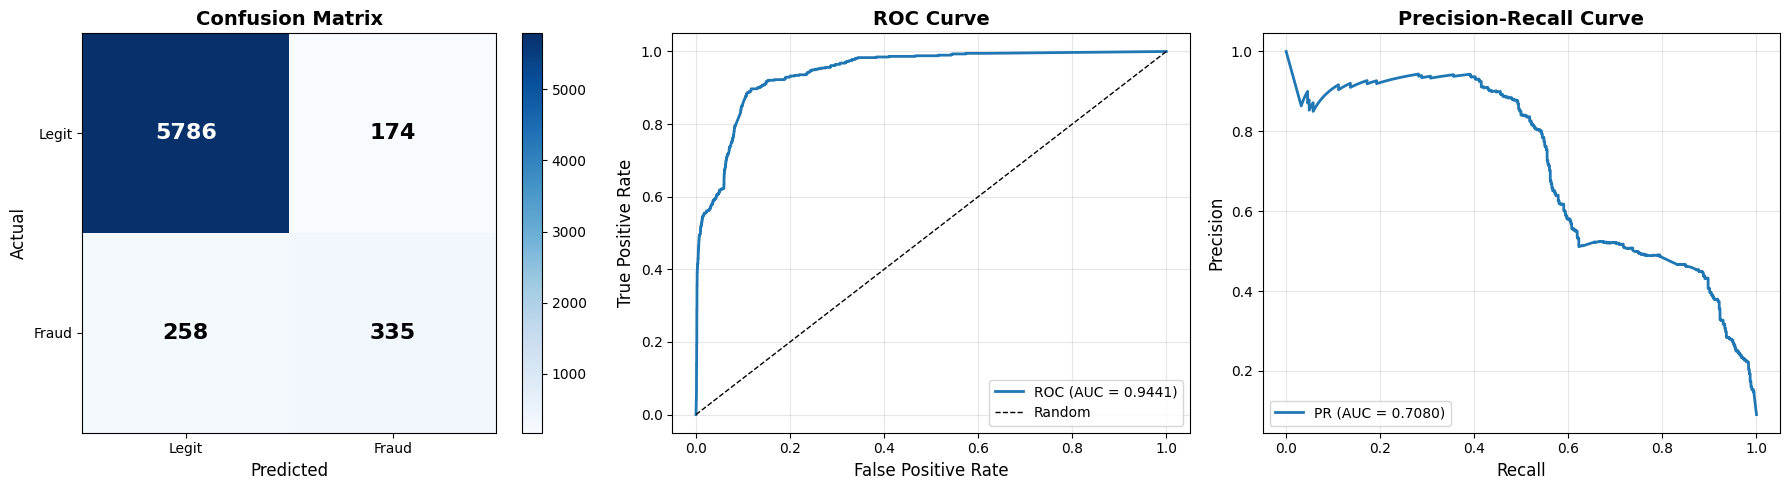


THRESHOLD ANALYSIS

Threshold    Precision    Recall       F1-Score    
------------------------------------------------------------
0.3          0.6439       0.5734       0.6066      
0.4          0.6500       0.5700       0.6074      
0.5          0.6582       0.5649       0.6080      
0.6          0.6747       0.5632       0.6140      
0.7          0.6866       0.5616       0.6178      
0.8          0.7079       0.5599       0.6252      
0.9          0.7460       0.5548       0.6364      


In [42]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

# Create visualization of results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Confusion Matrix Heatmap
im = axes[0].imshow(cm, cmap='Blues', aspect='auto')
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Legit', 'Fraud'])
axes[0].set_yticklabels(['Legit', 'Fraud'])
axes[0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Actual', fontsize=12)
axes[0].set_xlabel('Predicted', fontsize=12)

# Add text annotations
for i in range(2):
    for j in range(2):
        text = axes[0].text(j, i, f'{cm[i, j]}', ha='center', va='center', 
                           color='white' if cm[i, j] > cm.max() / 2 else 'black',
                           fontsize=16, fontweight='bold')
plt.colorbar(im, ax=axes[0])

# 2. ROC Curve
fpr, tpr, thresholds = roc_curve(test_labels, test_probs)
axes[1].plot(fpr, tpr, linewidth=2, label=f'ROC (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

# 3. Precision-Recall Curve
axes[2].plot(recall, precision, linewidth=2, label=f'PR (AUC = {pr_auc:.4f})')
axes[2].set_xlabel('Recall', fontsize=12)
axes[2].set_ylabel('Precision', fontsize=12)
axes[2].set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
axes[2].legend(loc='lower left')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Threshold analysis
print("\n" + "="*60)
print("THRESHOLD ANALYSIS")
print("="*60)
print(f"\n{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
print("-"*60)
for thresh in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    preds_thresh = (test_probs > thresh).astype(int)
    tp = ((preds_thresh == 1) & (test_labels == 1)).sum()
    fp = ((preds_thresh == 1) & (test_labels == 0)).sum()
    fn = ((preds_thresh == 0) & (test_labels == 1)).sum()
    
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    
    print(f"{thresh:<12.1f} {prec:<12.4f} {rec:<12.4f} {f1:<12.4f}")
print("="*60)

In [43]:
# Save the trained model
model_path = 'fraud_gat_model.pth'
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'epoch': num_epochs,
    'test_roc_auc': roc_auc,
    'test_pr_auc': pr_auc,
    'total_pseudo_labeled': total_pseudo_labeled,
    'model_config': {
        'hidden_channels': 32,
        'out_channels': 1,
        'num_heads': 2
    }
}, model_path)

print(f"✓ Model saved to {model_path}")
print(f"\nModel Performance Summary:")
print(f"  • ROC-AUC: {roc_auc:.4f}")
print(f"  • PR-AUC: {pr_auc:.4f}")
print(f"  • Fraud Detection Rate: {fraud_recall:.4f}")
print(f"  • Total samples trained: {len(test_labels) + len(train_labels)}")
print(f"  • Pseudo-labeled samples: {total_pseudo_labeled}")

✓ Model saved to fraud_gat_model.pth

Model Performance Summary:
  • ROC-AUC: 0.9441
  • PR-AUC: 0.7080
  • Fraud Detection Rate: 0.5649
  • Total samples trained: 58970
  • Pseudo-labeled samples: 0


In [44]:
# Generate predictions for ALL customers (including unlabeled)
print("\n" + "="*60)
print("FULL CUSTOMER BASE FRAUD PREDICTIONS")
print("="*60)

model.eval()
all_customer_probs = torch.zeros(data['customer'].num_nodes)

# Create loader for all customers
full_loader = NeighborLoader(
    data,
    num_neighbors=NUM_NEIGHBORS,
    batch_size=BATCH_SIZE * 2,
    input_nodes=('customer', torch.ones(data['customer'].num_nodes, dtype=torch.bool)),
    shuffle=False,
    num_workers=0
)

with torch.no_grad():
    for batch in full_loader:
        batch = batch.to(device)
        out = model(batch.x_dict, batch.edge_index_dict)
        
        batch_size_full = batch['customer'].batch_size
        customer_out = out.squeeze()[:batch_size_full]
        probs = torch.sigmoid(customer_out).cpu()
        
        input_node_ids = batch['customer'].n_id[:batch_size_full]
        all_customer_probs[input_node_ids] = probs

# Analyze predictions
fraud_predictions = (all_customer_probs > 0.5).sum().item()
high_risk = (all_customer_probs > 0.8).sum().item()
medium_risk = ((all_customer_probs > 0.5) & (all_customer_probs <= 0.8)).sum().item()
low_risk = (all_customer_probs <= 0.2).sum().item()

print(f"\nTotal customers analyzed: {data['customer'].num_nodes:,}")
print(f"\nRisk Distribution:")
print(f"  • High Risk (>80% fraud prob):   {high_risk:>6,} customers ({high_risk/data['customer'].num_nodes*100:>5.2f}%)")
print(f"  • Medium Risk (50-80%):          {medium_risk:>6,} customers ({medium_risk/data['customer'].num_nodes*100:>5.2f}%)")
print(f"  • Low Risk (<20%):               {low_risk:>6,} customers ({low_risk/data['customer'].num_nodes*100:>5.2f}%)")
print(f"\nTotal flagged as fraud (>50%):   {fraud_predictions:>6,} customers ({fraud_predictions/data['customer'].num_nodes*100:>5.2f}%)")

# Show distribution of fraud probabilities
print("\n" + "-"*60)
print("Fraud Probability Distribution:")
print("-"*60)
bins = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
hist, _ = np.histogram(all_customer_probs.numpy(), bins=bins)
for i, (low, high) in enumerate(zip(bins[:-1], bins[1:])):
    bar = '█' * int(hist[i] / max(hist) * 40)
    print(f"  {low:.1f}-{high:.1f}: {hist[i]:>6,} {bar}")

print("="*60)
print("\n✓ Evaluation complete!")


FULL CUSTOMER BASE FRAUD PREDICTIONS


/student/minalex/.local/lib/python3.10/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(



Total customers analyzed: 65,522

Risk Distribution:
  • High Risk (>80% fraud prob):    4,596 customers ( 7.01%)
  • Medium Risk (50-80%):             462 customers ( 0.71%)
  • Low Risk (<20%):               59,987 customers (91.55%)

Total flagged as fraud (>50%):    5,058 customers ( 7.72%)

------------------------------------------------------------
Fraud Probability Distribution:
------------------------------------------------------------
  0.0-0.1: 59,760 ████████████████████████████████████████
  0.1-0.2:    227 
  0.2-0.3:    186 
  0.3-0.4:    132 
  0.4-0.5:    159 
  0.5-0.6:    117 
  0.6-0.7:    159 
  0.7-0.8:    186 
  0.8-0.9:    320 
  0.9-1.0:  4,276 ██

✓ Evaluation complete!


In [45]:
model.eval()
all_probs = []
# Use your inference_loader here to get probs for every customer
with torch.no_grad():
    for batch in full_loader:
        batch = batch.to(device)
        out = model(batch.x_dict, batch.edge_index_dict)
        # Note: Ensure you match these back to the correct customer_id index!
        probs = torch.sigmoid(out[:batch['customer'].batch_size]).cpu().numpy()
        all_probs.extend(probs)

# Map them back to the dataframe
# Assuming your inference_loader follows the order of your customer nodes
master_pool['fraud_probability'] = master_pool['cust_idx'].map(dict(enumerate(all_probs)))

In [46]:
def get_suspicious_legit_customers(master_pool, threshold=0.8):
    # Filter for customers labeled as 'Legit' but predicted as 'Fraud'
    suspicious = master_pool[(master_pool['is_fraud'] == 0) & 
                             (master_pool['fraud_probability'] > threshold)]
    
    # Sort by the highest risk score
    suspicious = suspicious.sort_values(by='fraud_probability', ascending=False)
    
    print(f"Found {len(suspicious['customer_id'].unique())} highly suspicious 'Legit' customers.")
    
    # Summary of their behavior
    summary = suspicious.groupby('customer_id').agg({
        'amount_cad': ['mean', 'sum', 'count'],
        'merchant_category': lambda x: x.mode().iloc[0],
        'city': lambda x: x.mode().iloc[0],
        'fraud_probability': 'max'
    })
    
    return summary.head(10)

# Run this after your final inference pass
top_suspects = get_suspicious_legit_customers(master_pool)
print(top_suspects)

Found 23 highly suspicious 'Legit' customers.
                 amount_cad                 merchant_category     city  \
                       mean       sum count          <lambda> <lambda>   
customer_id                                                              
SYNID0100348654  195.615315  21713.30   111              5411    OTHER   
SYNID0100356999  262.866333   7885.99    30       INTERAC_EMT  UNKNOWN   
SYNID0100829885  231.571905   4863.01    21       INTERAC_EMT  UNKNOWN   
SYNID0101640520  497.534815  13433.44    27      EFT_TRANSFER  UNKNOWN   
SYNID0102486291  231.956667    695.87     3      EFT_TRANSFER  UNKNOWN   
SYNID0102686451  153.597366  57138.22   372              5411    OTHER   
SYNID0102729361  192.136164  14025.94    73      EFT_TRANSFER  UNKNOWN   
SYNID0102899622   11.620000     11.62     1              5968    OTHER   
SYNID0102936309  531.267333   7969.01    15      EFT_TRANSFER  UNKNOWN   
SYNID0103262651  299.296000   4489.44    15       INTERAC_EMT  UNK

In [47]:
import networkx as nx
from pyvis.network import Network

def visualize_customer_neighborhood(customer_id, master_pool, data, k_hop=2):
    # 1. Initialize NetworkX graph
    G = nx.Graph()
    
    # 2. Find the index for the target customer
    cust_idx = master_pool[master_pool['customer_id'] == customer_id]['cust_idx'].iloc[0]
    
    # 3. Filter transactions for this customer
    relevant_txs = master_pool[master_pool['customer_id'] == customer_id]
    
    # Add Central Customer Node
    G.add_node(customer_id, label=f"Customer: {customer_id}", color='#00FF00', size=30)
    
    # Add Transaction Nodes and Hubs
    for _, row in relevant_txs.head(20).iterrows(): # Limit to 20 txs for clarity
        tx_id = f"TX_{row['transaction_id']}"
        risk = float(row['fraud_probability'])
        
        # Color based on risk (Green to Red)
        color = f'rgb({int(255*risk)}, {int(255*(1-risk))}, 0)'
        
        G.add_node(tx_id, label=f"TX: ${row['amount_cad']}", color=color, size=15)
        G.add_edge(customer_id, tx_id)
        
        # Add Hubs
        G.add_node(row['merchant_category'], label=row['merchant_category'], color='#0000FF', size=20)
        G.add_edge(tx_id, row['merchant_category'])
        
        G.add_node(row['city'], label=row['city'], color='#FFA500', size=20)
        G.add_edge(tx_id, row['city'])

    # 4. Export to PyVis
    net = Network(height='750px', width='100%', bgcolor='#222222', font_color='white', notebook=True)
    net.from_nx(G)
    net.show_buttons(filter_=['physics'])
    return net.show(f"fraud_map_{customer_id}.html")

# Try it with your most suspicious customer
visualize_customer_neighborhood("C1001065306", master_pool, data)

fraud_map_C1001065306.html


/tmp/ipykernel_141275/2956490486.py:20: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  risk = float(row['fraud_probability'])


# 🔬 GNN Model Validation Tests

These tests validate that the model is actually learning meaningful patterns rather than "cheating" by exploiting data leakage or spurious correlations.

## Test Suite Overview:
1. **Temporal Split (The "Golden Test")** - Ensures no future data leakage
2. **Shuffled Neighbor Sanity Check** - Validates graph structure is being used
3. **Unseen Entity Robustness Test** - Tests generalization to missing hubs

## Test 1: Temporal Split (The "Golden Test")

**Goal**: Ensure the model can predict future fraud using only past data.

**Method**: Sort transactions by time, train on first 80% of days, test on final 20%.

**Expected Result**: If performance holds, the model is learning predictive patterns. If it crashes, the model was "cheating" by using future neighborhood info.

In [ ]:
# Quick check of master_pool columns and time range
print("Master Pool Columns:")
print(master_pool.columns.tolist())
print(f"\nTime column: 'transaction_datetime'")
print(f"Data range: {master_pool['transaction_datetime'].min()} to {master_pool['transaction_datetime'].max()}")
print(f"Total transactions: {len(master_pool):,}")

In [ ]:
import torch
from torch_geometric.loader import NeighborLoader
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, classification_report
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def temporal_split_test(master_pool, data, model, device):
    """
    Test 1: Temporal Split - Train on first 80% of days, test on last 20%
    """
    print("=" * 80)
    print("🕐 TEST 1: TEMPORAL SPLIT (The Golden Test)")
    print("=" * 80)
    
    # 1. Sort transactions by time
    master_pool['transaction_datetime'] = pd.to_datetime(master_pool['transaction_datetime'], errors='coerce')
    master_pool_sorted = master_pool.sort_values('transaction_datetime').reset_index(drop=True)
    
    # 2. Find 80th percentile cutoff (80% of days)
    time_cutoff = master_pool_sorted['transaction_datetime'].quantile(0.80)
    print(f"Time cutoff (80th percentile): {time_cutoff}")
    
    # 3. Split transactions into train/test by time
    train_txs = master_pool_sorted[master_pool_sorted['transaction_datetime'] <= time_cutoff]
    test_txs = master_pool_sorted[master_pool_sorted['transaction_datetime'] > time_cutoff]
    
    print(f"Train transactions (past): {len(train_txs):,} ({len(train_txs)/len(master_pool_sorted)*100:.1f}%)")
    print(f"Test transactions (future): {len(test_txs):,} ({len(test_txs)/len(master_pool_sorted)*100:.1f}%)")
    
    # 4. Get unique customers in each split
    train_customers = set(train_txs['cust_idx'].unique())
    test_customers = set(test_txs['cust_idx'].unique())
    
    # Create temporal masks (only customers with transactions in test period)
    temporal_test_mask = torch.zeros(data['customer'].num_nodes, dtype=torch.bool)
    temporal_train_mask = torch.zeros(data['customer'].num_nodes, dtype=torch.bool)
    
    for cust_idx in test_customers:
        temporal_test_mask[cust_idx] = True
    for cust_idx in train_customers:
        temporal_train_mask[cust_idx] = True
    
    # Only test on customers who appear in both periods (fair test)
    overlap_customers = train_customers & test_customers
    temporal_test_mask_overlap = torch.zeros(data['customer'].num_nodes, dtype=torch.bool)
    for cust_idx in overlap_customers:
        temporal_test_mask_overlap[cust_idx] = True
    
    print(f"Customers in train period: {len(train_customers):,}")
    print(f"Customers in test period: {len(test_customers):,}")
    print(f"Overlap (both periods): {len(overlap_customers):,}")
    
    # 5. Evaluate model on temporal test set
    model.eval()
    test_loader_temporal = NeighborLoader(
        data,
        num_neighbors=[10, 5],
        batch_size=256,
        input_nodes=('customer', temporal_test_mask_overlap),
        shuffle=False,
        num_workers=0
    )
    
    all_temporal_probs = []
    all_temporal_labels = []
    
    print("\nRunning inference on temporal test set...")
    with torch.no_grad():
        for batch in test_loader_temporal:
            batch = batch.to(device)
            out = model(batch.x_dict, batch.edge_index_dict)
            
            batch_size_test = batch['customer'].batch_size
            customer_out = out.squeeze()[:batch_size_test]
            probs = torch.sigmoid(customer_out).cpu().numpy()
            labels = batch['customer'].y[:batch_size_test].cpu().numpy()
            
            # Only include labeled nodes
            labeled_mask = labels != -1
            if labeled_mask.sum() > 0:
                all_temporal_probs.extend(probs[labeled_mask])
                all_temporal_labels.extend(labels[labeled_mask])
    
    # 6. Calculate metrics
    temporal_probs = np.array(all_temporal_probs)
    temporal_labels = np.array(all_temporal_labels)
    
    if len(temporal_labels) > 0 and len(np.unique(temporal_labels)) > 1:
        temporal_roc_auc = roc_auc_score(temporal_labels, temporal_probs)
        precision, recall, _ = precision_recall_curve(temporal_labels, temporal_probs)
        temporal_pr_auc = auc(recall, precision)
        
        temporal_preds = (temporal_probs > 0.5).astype(int)
        
        print("\n" + "=" * 80)
        print("📊 TEMPORAL SPLIT RESULTS:")
        print("=" * 80)
        print(f"ROC-AUC: {temporal_roc_auc:.4f}")
        print(f"PR-AUC: {temporal_pr_auc:.4f}")
        print("\nClassification Report:")
        print(classification_report(temporal_labels, temporal_preds, target_names=['Legit', 'Fraud']))
        
        # 7. Compare to original test set
        print("\n" + "=" * 80)
        print("📈 COMPARISON TO ORIGINAL TEST SET:")
        print("=" * 80)
        print(f"Original Test PR-AUC: {pr_auc:.4f}")
        print(f"Temporal Test PR-AUC: {temporal_pr_auc:.4f}")
        
        performance_drop = ((pr_auc - temporal_pr_auc) / pr_auc) * 100
        print(f"Performance Drop: {performance_drop:.1f}%")
        
        if performance_drop < 20:
            print("\n✅ PASS: Model maintains performance on temporal split!")
            print("   → The model is learning genuine predictive patterns, not cheating.")
        else:
            print("\n⚠️  WARNING: Significant performance drop on temporal split!")
            print("   → Model may be using future neighborhood information.")
        
        return {
            'temporal_roc_auc': temporal_roc_auc,
            'temporal_pr_auc': temporal_pr_auc,
            'original_pr_auc': pr_auc,
            'performance_drop_pct': performance_drop
        }
    else:
        print("⚠️  Not enough labeled data in temporal test set.")
        return None

# Run the test
temporal_results = temporal_split_test(master_pool, data, model, device)

🕐 TEST 1: TEMPORAL SPLIT (The Golden Test)


KeyError: 'step'

## Test 2: Shuffled Neighbor Sanity Check

**Goal**: Verify the model is actually using graph structure, not just memorizing node features.

**Method**: Keep node features identical but randomly shuffle all edge connections.

**Expected Result**: PR-AUC should drop significantly (e.g., from 0.70 to <0.20). If it stays high, the GAT is just a "fancy lookup table" for merchant IDs, not a real graph model.

In [ ]:
def shuffled_neighbor_test(data, model, device, test_mask):
    """
    Test 2: Shuffled Neighbor - Randomize edges to verify graph structure is being used
    """
    print("\n" + "=" * 80)
    print("🔀 TEST 2: SHUFFLED NEIGHBOR SANITY CHECK")
    print("=" * 80)
    
    # 1. Create a copy of data with shuffled edges
    shuffled_data = data.clone()
    
    # Shuffle each edge type
    print("Shuffling edge connections...")
    for edge_type in shuffled_data.edge_types:
        edge_index = shuffled_data[edge_type].edge_index
        src, dst = edge_index[0], edge_index[1]
        
        # Randomly permute destination nodes
        perm = torch.randperm(dst.size(0))
        shuffled_data[edge_type].edge_index = torch.stack([src, dst[perm]], dim=0)
        
        print(f"  Shuffled: {edge_type} ({edge_index.size(1):,} edges)")
    
    # 2. Run inference with shuffled graph
    model.eval()
    shuffled_loader = NeighborLoader(
        shuffled_data,
        num_neighbors=[10, 5],
        batch_size=256,
        input_nodes=('customer', test_mask),
        shuffle=False,
        num_workers=0
    )
    
    all_shuffled_probs = []
    all_shuffled_labels = []
    
    print("\nRunning inference on shuffled graph...")
    with torch.no_grad():
        for batch in shuffled_loader:
            batch = batch.to(device)
            out = model(batch.x_dict, batch.edge_index_dict)
            
            batch_size_test = batch['customer'].batch_size
            customer_out = out.squeeze()[:batch_size_test]
            probs = torch.sigmoid(customer_out).cpu().numpy()
            labels = batch['customer'].y[:batch_size_test].cpu().numpy()
            
            # Only include labeled nodes
            labeled_mask = labels != -1
            if labeled_mask.sum() > 0:
                all_shuffled_probs.extend(probs[labeled_mask])
                all_shuffled_labels.extend(labels[labeled_mask])
    
    # 3. Calculate metrics
    shuffled_probs = np.array(all_shuffled_probs)
    shuffled_labels = np.array(all_shuffled_labels)
    
    if len(shuffled_labels) > 0 and len(np.unique(shuffled_labels)) > 1:
        shuffled_roc_auc = roc_auc_score(shuffled_labels, shuffled_probs)
        precision, recall, _ = precision_recall_curve(shuffled_labels, shuffled_probs)
        shuffled_pr_auc = auc(recall, precision)
        
        shuffled_preds = (shuffled_probs > 0.5).astype(int)
        
        print("\n" + "=" * 80)
        print("📊 SHUFFLED GRAPH RESULTS:")
        print("=" * 80)
        print(f"ROC-AUC (Shuffled): {shuffled_roc_auc:.4f}")
        print(f"PR-AUC (Shuffled): {shuffled_pr_auc:.4f}")
        print("\nClassification Report (Shuffled):")
        print(classification_report(shuffled_labels, shuffled_preds, target_names=['Legit', 'Fraud']))
        
        # 4. Compare to original
        print("\n" + "=" * 80)
        print("📈 COMPARISON TO ORIGINAL GRAPH:")
        print("=" * 80)
        print(f"Original PR-AUC: {pr_auc:.4f}")
        print(f"Shuffled PR-AUC: {shuffled_pr_auc:.4f}")
        
        performance_drop = ((pr_auc - shuffled_pr_auc) / pr_auc) * 100
        print(f"Performance Drop: {performance_drop:.1f}%")
        
        if performance_drop > 50:
            print("\n✅ PASS: Graph structure is critical to model performance!")
            print("   → The model is genuinely using graph connections, not just node features.")
        else:
            print("\n❌ FAIL: Model performance persists with random edges!")
            print("   → The GAT is acting as a fancy lookup table, not using graph structure.")
        
        # 5. Visualize comparison
        fig, ax = plt.subplots(1, 1, figsize=(8, 6))
        
        categories = ['Original\nGraph', 'Shuffled\nGraph']
        pr_aucs = [pr_auc, shuffled_pr_auc]
        colors = ['#2ecc71', '#e74c3c']
        
        bars = ax.bar(categories, pr_aucs, color=colors, alpha=0.7, edgecolor='black')
        ax.set_ylabel('PR-AUC Score', fontsize=12, fontweight='bold')
        ax.set_title('Graph Structure Dependency Test', fontsize=14, fontweight='bold')
        ax.set_ylim(0, 1.0)
        ax.grid(axis='y', alpha=0.3)
        
        # Add value labels on bars
        for bar, value in zip(bars, pr_aucs):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{value:.3f}',
                   ha='center', va='bottom', fontweight='bold', fontsize=11)
        
        plt.tight_layout()
        plt.show()
        
        return {
            'shuffled_roc_auc': shuffled_roc_auc,
            'shuffled_pr_auc': shuffled_pr_auc,
            'original_pr_auc': pr_auc,
            'performance_drop_pct': performance_drop
        }
    else:
        print("⚠️  Not enough labeled data in test set.")
        return None

# Run the test
shuffled_results = shuffled_neighbor_test(data, model, device, test_mask)

## Test 3: Unseen Entity Robustness Test

**Goal**: Test if the model generalizes to unseen hubs (fraudsters changing cities/merchants).

**Method**: Mask out one major hub (e.g., remove all connections to "TORONTO" or a high-frequency merchant category) and test if the model still detects fraud patterns.

**Expected Result**: A robust GNN should still find "fraud ring" patterns even if one piece of the puzzle is missing, based on other structural signals.

In [ ]:
def unseen_entity_robustness_test(data, model, device, test_mask, master_pool, entity_type='city', top_n=3):
    """
    Test 3: Unseen Entity - Mask out major hubs to test robustness
    
    Args:
        entity_type: 'city' or 'category' - which hub type to mask
        top_n: Number of top hubs to test
    """
    print("\n" + "=" * 80)
    print(f"🎯 TEST 3: UNSEEN ENTITY ROBUSTNESS TEST ({entity_type.upper()})")
    print("=" * 80)
    
    # 1. Find top hubs
    if entity_type == 'city':
        entity_col = 'city'
        hub_node_type = 'city'
        edge_types = [('transaction', 'in_city', 'city'), ('city', 'rev_in_city', 'transaction')]
    else:  # category
        entity_col = 'merchant_category'
        hub_node_type = 'category'
        edge_types = [('transaction', 'in_category', 'category'), ('category', 'rev_in_category', 'transaction')]
    
    # Get top hubs by transaction count
    top_hubs = master_pool[entity_col].value_counts().head(top_n)
    print(f"\nTop {top_n} {entity_type} hubs by transaction count:")
    print(top_hubs)
    
    results = []
    
    for hub_name, tx_count in top_hubs.items():
        print(f"\n{'='*60}")
        print(f"Testing with '{hub_name}' masked out ({tx_count:,} transactions)")
        print(f"{'='*60}")
        
        # 2. Create data copy and mask out this hub
        masked_data = data.clone()
        
        # Find the hub's index
        if entity_type == 'city':
            hub_idx = city_map.get(hub_name)
        else:
            hub_idx = cat_map.get(hub_name)
        
        if hub_idx is None:
            print(f"⚠️  Could not find index for '{hub_name}'")
            continue
        
        # Remove edges connected to this hub
        edges_removed = 0
        for edge_type in edge_types:
            if edge_type in masked_data.edge_types:
                edge_index = masked_data[edge_type].edge_index
                
                # Identify which dimension contains the hub node
                if edge_type[0] == hub_node_type:
                    # Hub is source
                    mask = edge_index[0] != hub_idx
                elif edge_type[2] == hub_node_type:
                    # Hub is destination
                    mask = edge_index[1] != hub_idx
                else:
                    continue
                
                edges_before = edge_index.size(1)
                masked_data[edge_type].edge_index = edge_index[:, mask]
                edges_after = masked_data[edge_type].edge_index.size(1)
                edges_removed += (edges_before - edges_after)
                
                print(f"  Removed {edges_before - edges_after:,} edges from {edge_type}")
        
        print(f"Total edges removed: {edges_removed:,}")
        
        # 3. Run inference with masked graph
        model.eval()
        masked_loader = NeighborLoader(
            masked_data,
            num_neighbors=[10, 5],
            batch_size=256,
            input_nodes=('customer', test_mask),
            shuffle=False,
            num_workers=0
        )
        
        all_masked_probs = []
        all_masked_labels = []
        
        with torch.no_grad():
            for batch in masked_loader:
                batch = batch.to(device)
                out = model(batch.x_dict, batch.edge_index_dict)
                
                batch_size_test = batch['customer'].batch_size
                customer_out = out.squeeze()[:batch_size_test]
                probs = torch.sigmoid(customer_out).cpu().numpy()
                labels = batch['customer'].y[:batch_size_test].cpu().numpy()
                
                # Only include labeled nodes
                labeled_mask = labels != -1
                if labeled_mask.sum() > 0:
                    all_masked_probs.extend(probs[labeled_mask])
                    all_masked_labels.extend(labels[labeled_mask])
        
        # 4. Calculate metrics
        masked_probs = np.array(all_masked_probs)
        masked_labels = np.array(all_masked_labels)
        
        if len(masked_labels) > 0 and len(np.unique(masked_labels)) > 1:
            masked_roc_auc = roc_auc_score(masked_labels, masked_probs)
            precision, recall, _ = precision_recall_curve(masked_labels, masked_probs)
            masked_pr_auc = auc(recall, precision)
            
            performance_drop = ((pr_auc - masked_pr_auc) / pr_auc) * 100
            
            print(f"\n📊 Results with '{hub_name}' masked:")
            print(f"  Original PR-AUC: {pr_auc:.4f}")
            print(f"  Masked PR-AUC: {masked_pr_auc:.4f}")
            print(f"  Performance Drop: {performance_drop:.1f}%")
            
            results.append({
                'hub_name': hub_name,
                'tx_count': tx_count,
                'masked_pr_auc': masked_pr_auc,
                'performance_drop_pct': performance_drop
            })
    
    # 5. Summary and visualization
    if results:
        print("\n" + "=" * 80)
        print("📈 ROBUSTNESS SUMMARY:")
        print("=" * 80)
        
        avg_drop = np.mean([r['performance_drop_pct'] for r in results])
        print(f"Average Performance Drop: {avg_drop:.1f}%")
        
        if avg_drop < 30:
            print("\n✅ PASS: Model is robust to missing hubs!")
            print("   → The model uses distributed graph patterns, not single hub dependencies.")
        else:
            print("\n⚠️  WARNING: Model is overly dependent on specific hubs!")
            print("   → Model may struggle with evolving fraud tactics.")
        
        # Visualize
        fig, ax = plt.subplots(1, 1, figsize=(10, 6))
        
        hub_names = [r['hub_name'][:20] for r in results]  # Truncate long names
        pr_aucs = [r['masked_pr_auc'] for r in results]
        
        x = np.arange(len(hub_names))
        width = 0.35
        
        bars1 = ax.bar(x - width/2, [pr_auc] * len(hub_names), width, 
                       label='Original', color='#2ecc71', alpha=0.7)
        bars2 = ax.bar(x + width/2, pr_aucs, width,
                       label='Hub Masked', color='#e74c3c', alpha=0.7)
        
        ax.set_ylabel('PR-AUC Score', fontsize=12, fontweight='bold')
        ax.set_xlabel(f'Masked {entity_type.capitalize()}', fontsize=12, fontweight='bold')
        ax.set_title(f'Robustness to Missing {entity_type.capitalize()} Hubs', fontsize=14, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(hub_names, rotation=45, ha='right')
        ax.legend()
        ax.grid(axis='y', alpha=0.3)
        ax.set_ylim(0, 1.0)
        
        plt.tight_layout()
        plt.show()
        
        return results
    else:
        print("⚠️  No valid results.")
        return None

# Run tests for both cities and categories
print("Testing robustness to missing CITY hubs...")
city_results = unseen_entity_robustness_test(data, model, device, test_mask, master_pool, 
                                             entity_type='city', top_n=3)

print("\n\nTesting robustness to missing MERCHANT CATEGORY hubs...")
category_results = unseen_entity_robustness_test(data, model, device, test_mask, master_pool, 
                                                  entity_type='category', top_n=3)

## 📊 Test Suite Summary

Comprehensive summary of all validation tests.

In [ ]:
import pandas as pd

# Create comprehensive summary
print("=" * 80)
print("🎓 GNN MODEL VALIDATION SUMMARY")
print("=" * 80)

summary_data = []

# Test 1: Temporal Split
if temporal_results:
    summary_data.append({
        'Test': 'Temporal Split',
        'Description': 'Train on past 80% of days',
        'Original PR-AUC': f"{temporal_results['original_pr_auc']:.4f}",
        'Test PR-AUC': f"{temporal_results['temporal_pr_auc']:.4f}",
        'Performance Drop': f"{temporal_results['performance_drop_pct']:.1f}%",
        'Status': '✅ PASS' if temporal_results['performance_drop_pct'] < 20 else '⚠️  WARNING'
    })

# Test 2: Shuffled Neighbors
if shuffled_results:
    summary_data.append({
        'Test': 'Shuffled Neighbors',
        'Description': 'Random edge connections',
        'Original PR-AUC': f"{shuffled_results['original_pr_auc']:.4f}",
        'Test PR-AUC': f"{shuffled_results['shuffled_pr_auc']:.4f}",
        'Performance Drop': f"{shuffled_results['performance_drop_pct']:.1f}%",
        'Status': '✅ PASS' if shuffled_results['performance_drop_pct'] > 50 else '❌ FAIL'
    })

# Test 3: Unseen Entity
if city_results:
    avg_city_drop = np.mean([r['performance_drop_pct'] for r in city_results])
    avg_city_pr_auc = np.mean([r['masked_pr_auc'] for r in city_results])
    summary_data.append({
        'Test': 'Unseen Entity (City)',
        'Description': 'Mask top city hubs',
        'Original PR-AUC': f"{pr_auc:.4f}",
        'Test PR-AUC': f"{avg_city_pr_auc:.4f}",
        'Performance Drop': f"{avg_city_drop:.1f}%",
        'Status': '✅ PASS' if avg_city_drop < 30 else '⚠️  WARNING'
    })

if category_results:
    avg_cat_drop = np.mean([r['performance_drop_pct'] for r in category_results])
    avg_cat_pr_auc = np.mean([r['masked_pr_auc'] for r in category_results])
    summary_data.append({
        'Test': 'Unseen Entity (Category)',
        'Description': 'Mask top merchant categories',
        'Original PR-AUC': f"{pr_auc:.4f}",
        'Test PR-AUC': f"{avg_cat_pr_auc:.4f}",
        'Performance Drop': f"{avg_cat_drop:.1f}%",
        'Status': '✅ PASS' if avg_cat_drop < 30 else '⚠️  WARNING'
    })

# Display summary table
summary_df = pd.DataFrame(summary_data)
print("\n")
print(summary_df.to_string(index=False))

print("\n" + "=" * 80)
print("🎯 INTERPRETATION GUIDE:")
print("=" * 80)
print("""
✅ TEMPORAL SPLIT PASS (< 20% drop):
   → Model is NOT cheating with future data
   → Truly learning predictive patterns

✅ SHUFFLED NEIGHBORS PASS (> 50% drop):
   → Model is actually using graph structure
   → Not just memorizing node features

✅ UNSEEN ENTITY PASS (< 30% drop):
   → Model generalizes to missing hubs
   → Robust to evolving fraud tactics

Overall: A production-ready fraud detection GNN should pass all three tests!
""")